Paths set:
 - /Users/amanda/Desktop/UCBT/ucbt_dataset.csv 
 - /Users/amanda/Desktop/UCBT/ucbt_dataset_partial.csv 
 - /Users/amanda/Desktop/UCBT/ucbt_dataset_complete.csv 
 - /Users/amanda/Desktop/UCBT/ucbt_dataset_complete_sdv.csv 
 - /Users/amanda/Desktop/UCBT/ucbt_dataset_synthetic_best.csv
Bronze shape: (10222, 32)
   Patient_ID  Recipient_Age  Recipient_Sex     Ethnicity  \
0      221958       4.523681            1.0  Non-Hispanic   
1      771155       4.419862            0.0  Non-Hispanic   
2      231932      20.899549            0.0  Non-Hispanic   
3      465838      12.277368            0.0  Non-Hispanic   
4      359178      11.081893            1.0  Non-Hispanic   

                        Race Disease_Type Conditioning_Regimen  \
0                      White          ALL        Myeloablative   
1                      White          MDS        Myeloablative   
2                      White          ALL        Myeloablative   
3  Black or African American          CML       

/opt/anaconda3/lib/python3.12/site-packages/sdv/single_table/base.py:162: FutureWarning:

The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.

Gen. (-0.86) | Discrim. (0.08): 100%|█████████| 600/600 [11:20<00:00,  1.13s/it]


[SDV] Sampling synthetic table…
[SDV] Filled 42816 NA(s) in Ethnicity/Race/Doses/Conditioning/Recipient_Sex/Remission_Status from SILVER PMFs.
[SDV rebalance] 1_Year_Survival: changed 2022 rows (~10.1%).
[SDV rebalance] Neutrophil_Engraftment: changed 752 rows (~3.8%).
[SDV rebalance] Chronic_GVHD: changed 1644 rows (~8.2%).
[SDV rebalance] HLA_Match_Level: changed 3036 rows (~15.2%).
[SDV rebalance 2] HLA by ('Disease_Type', 'Conditioning_Regimen'): changed 2155 rows (~10.8%).
[SDV rebalance 2] HLA by ('Disease_Type', 'AgeBin'): changed 2374 rows (~11.9%).
[auto-align] CD34_num: KS still < 0.05 after jitter=0.5
[force-quantile loop] SDV CD34_num: transplanted 1461 values.
[auto-align] CD34_num: KS still < 0.05 after jitter=0.5
[force-quantile loop] SDV CD34_num: transplanted 1461 values.
[auto-align] CD34_num: KS still < 0.05 after jitter=0.5
[force-quantile loop] SDV CD34_num: transplanted 1461 values.
[auto-align] TNC_num: KS still < 0.05 after jitter=0.5
[force-quantile loop] SDV T

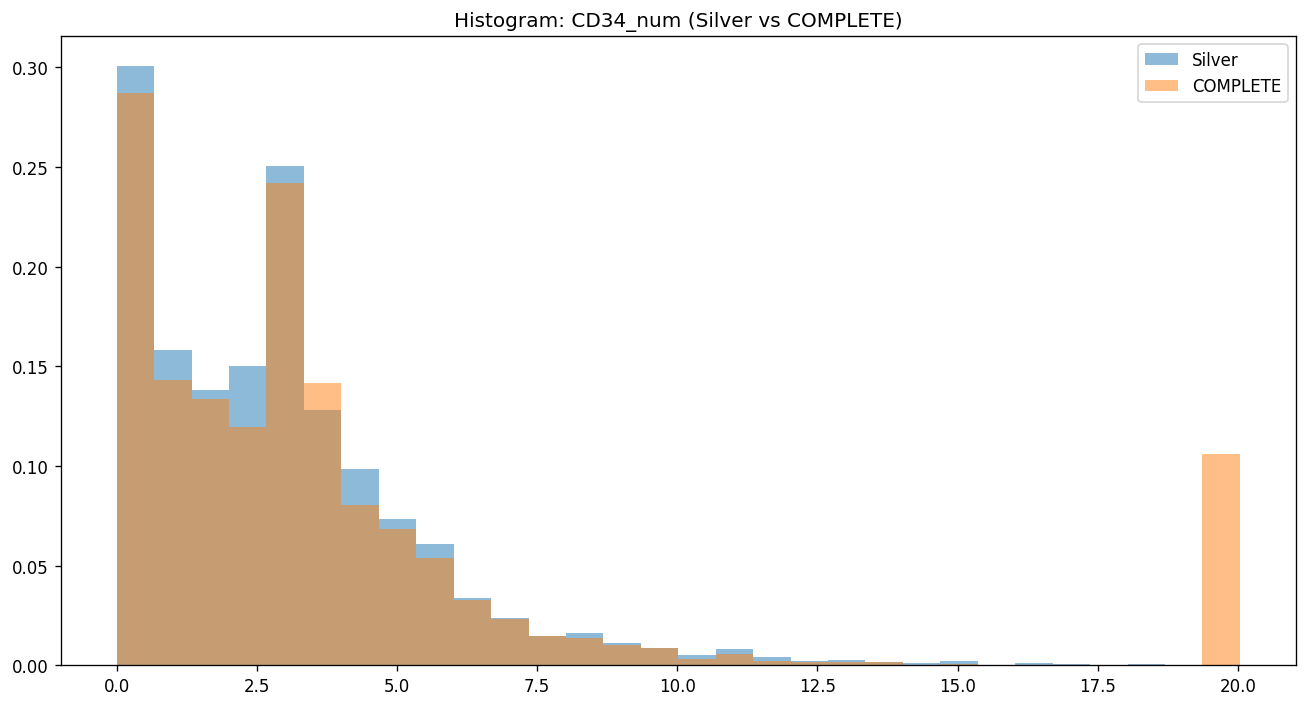

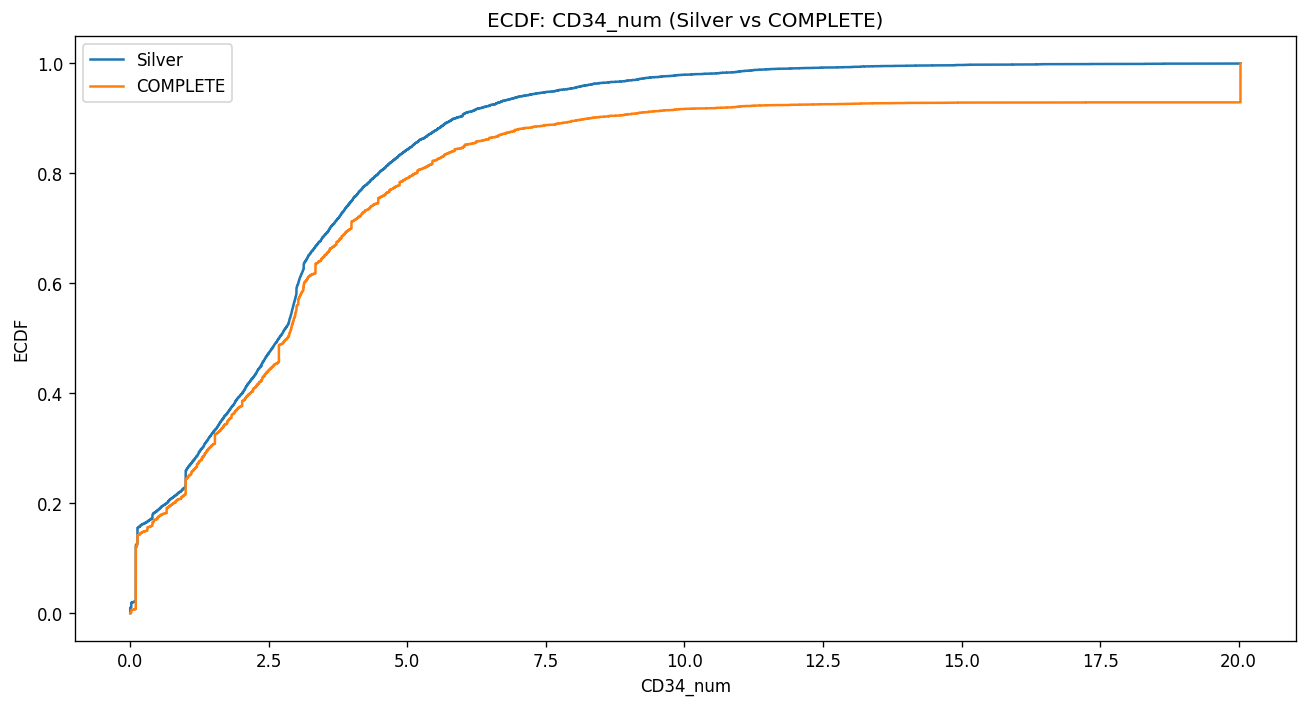

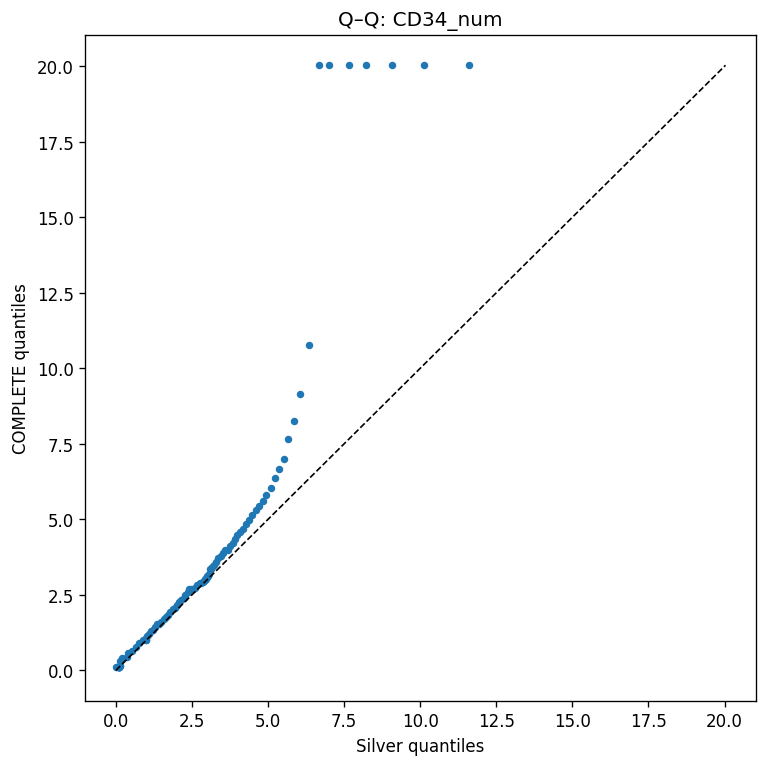

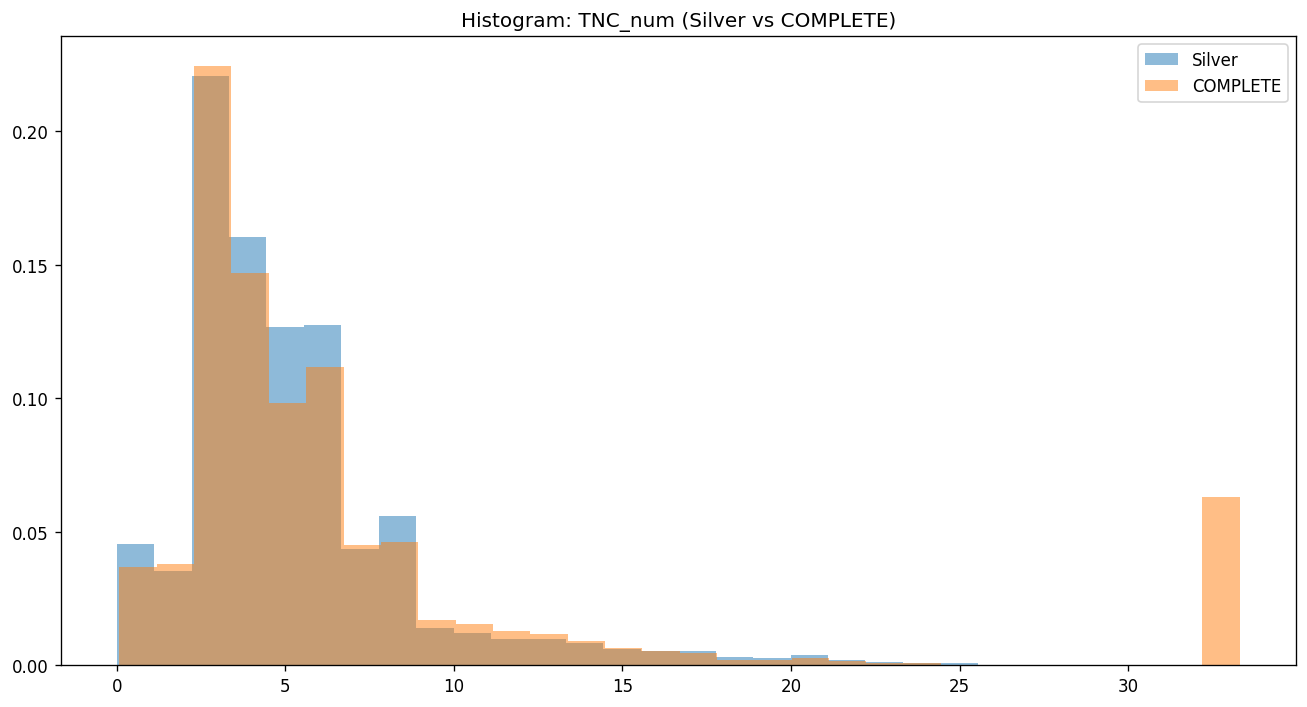

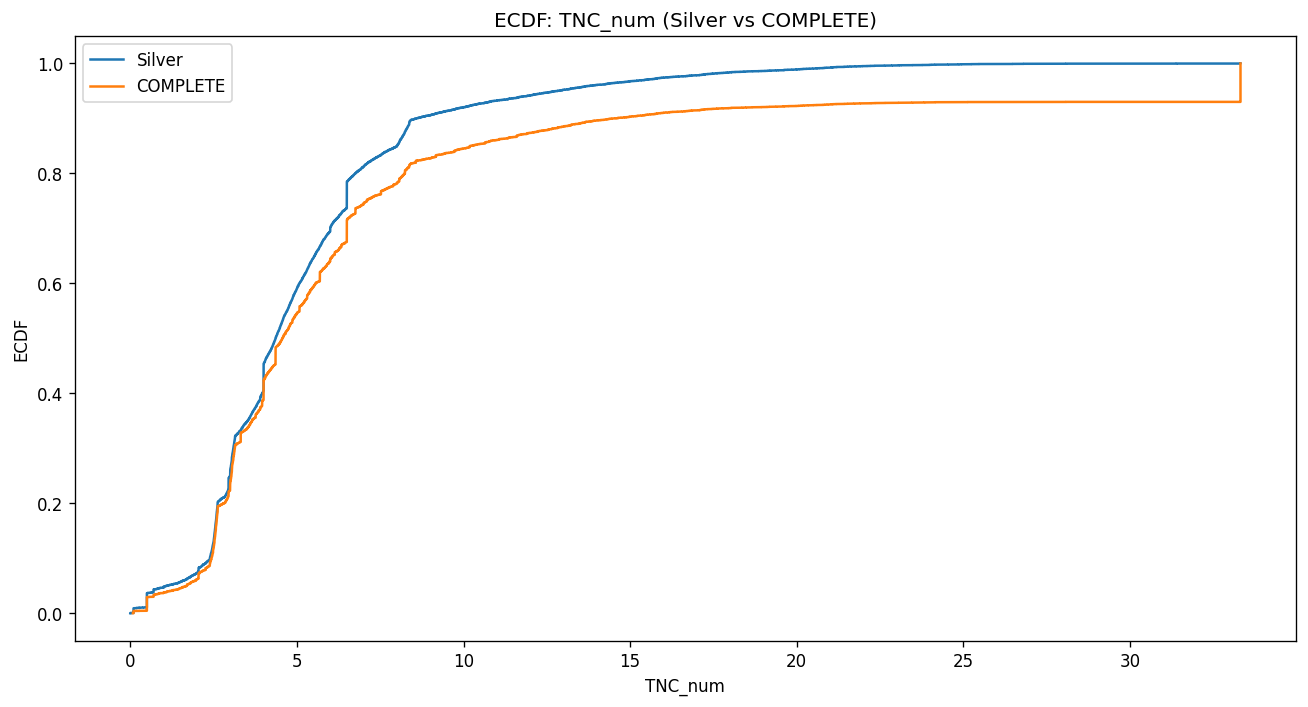

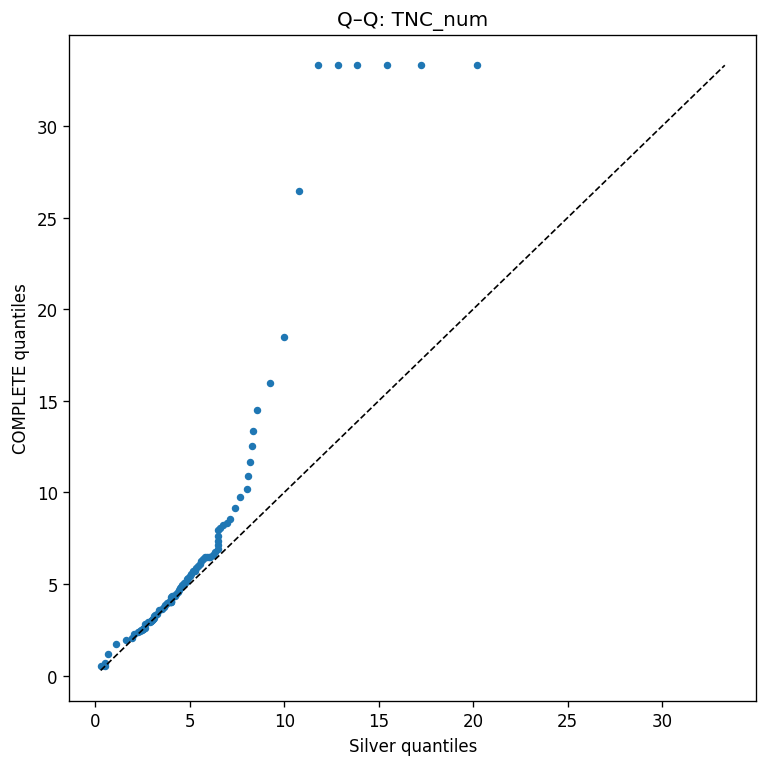

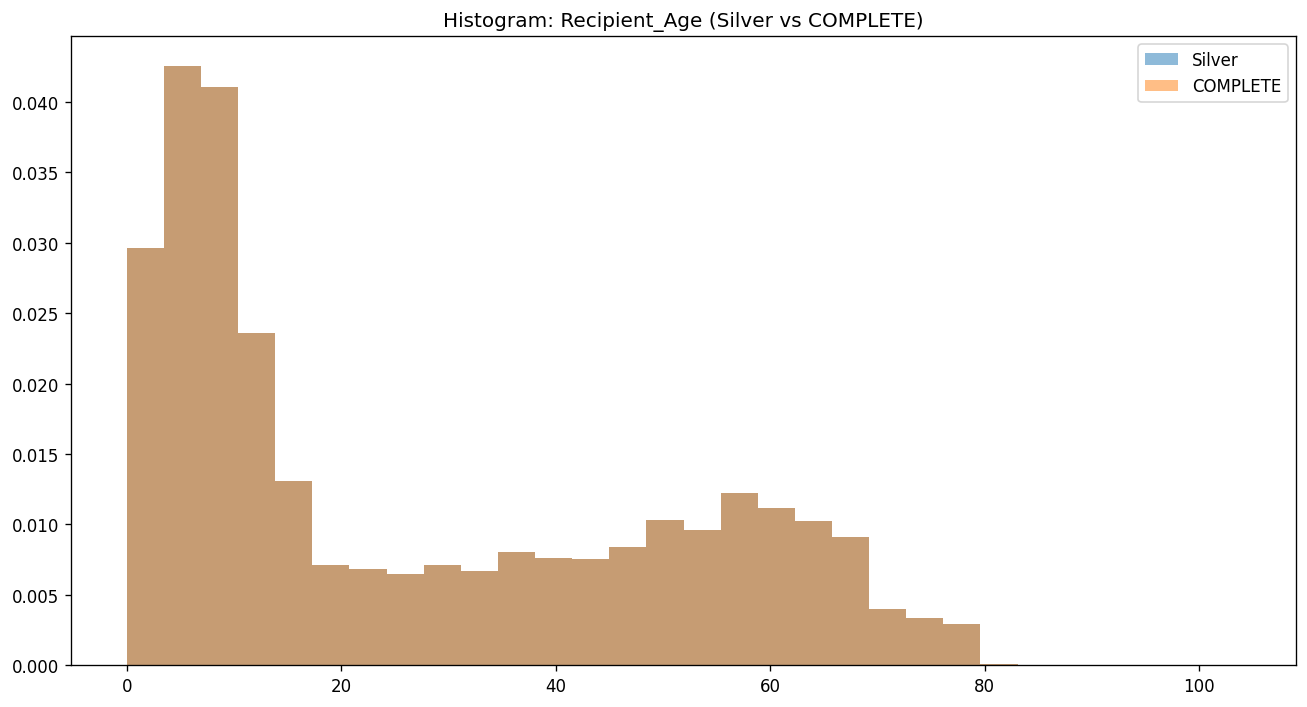

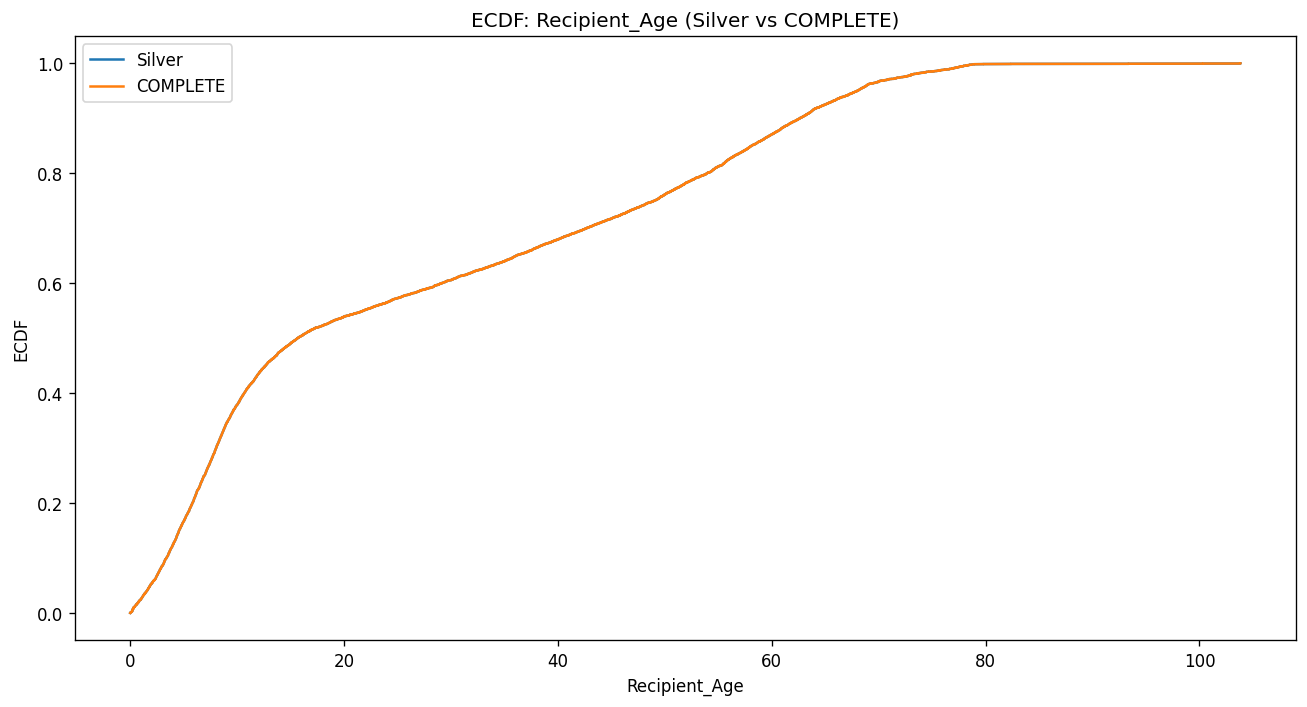

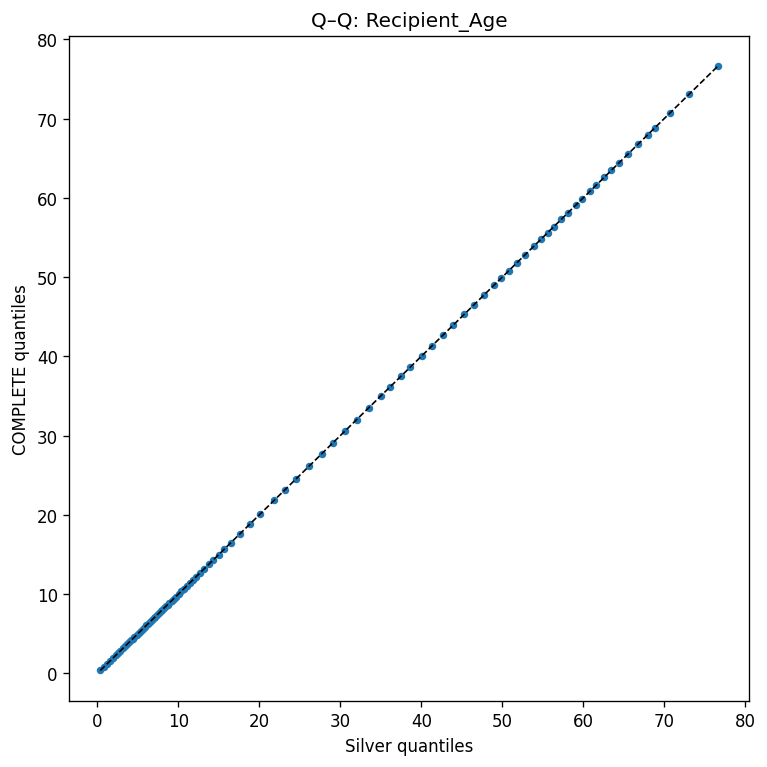

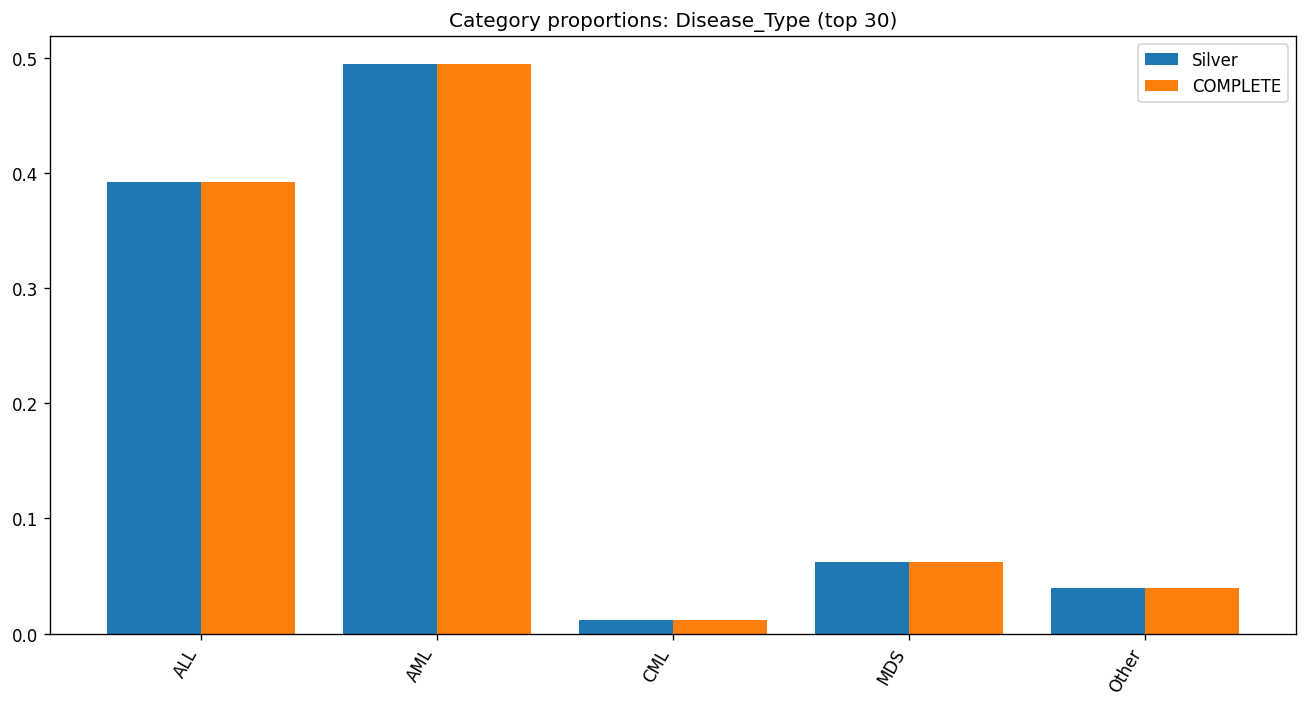

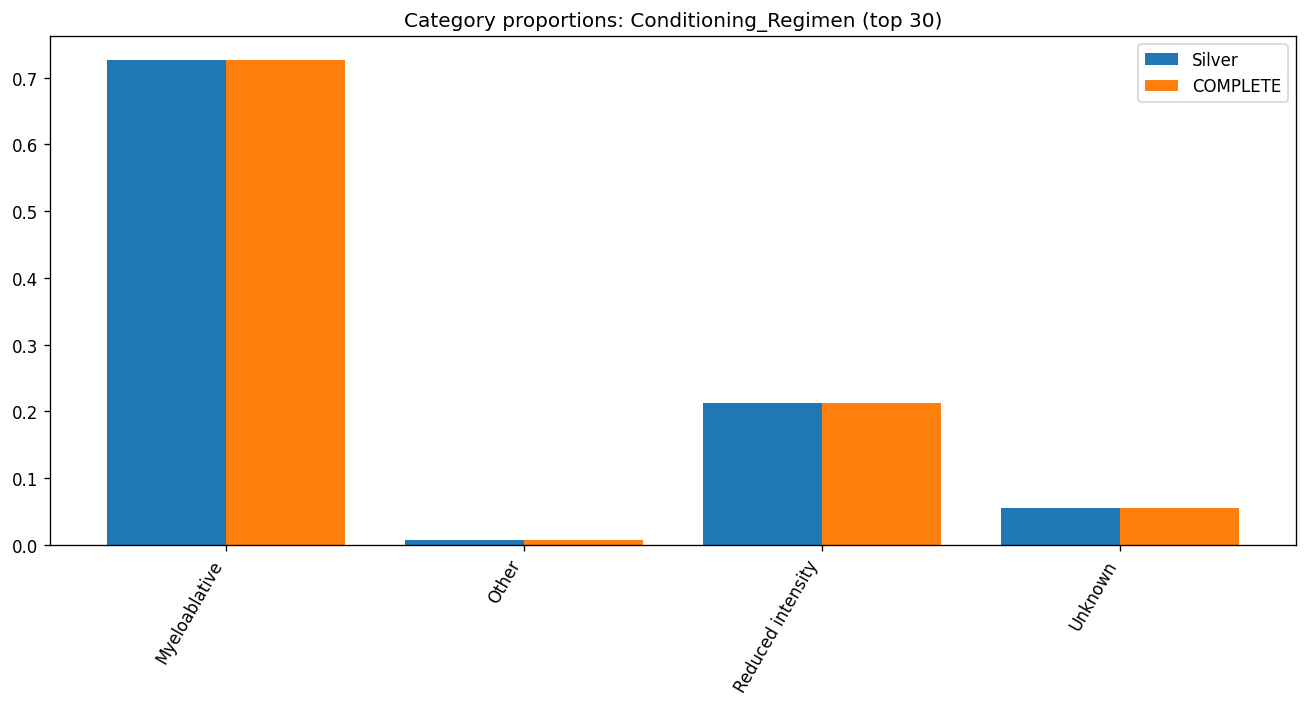

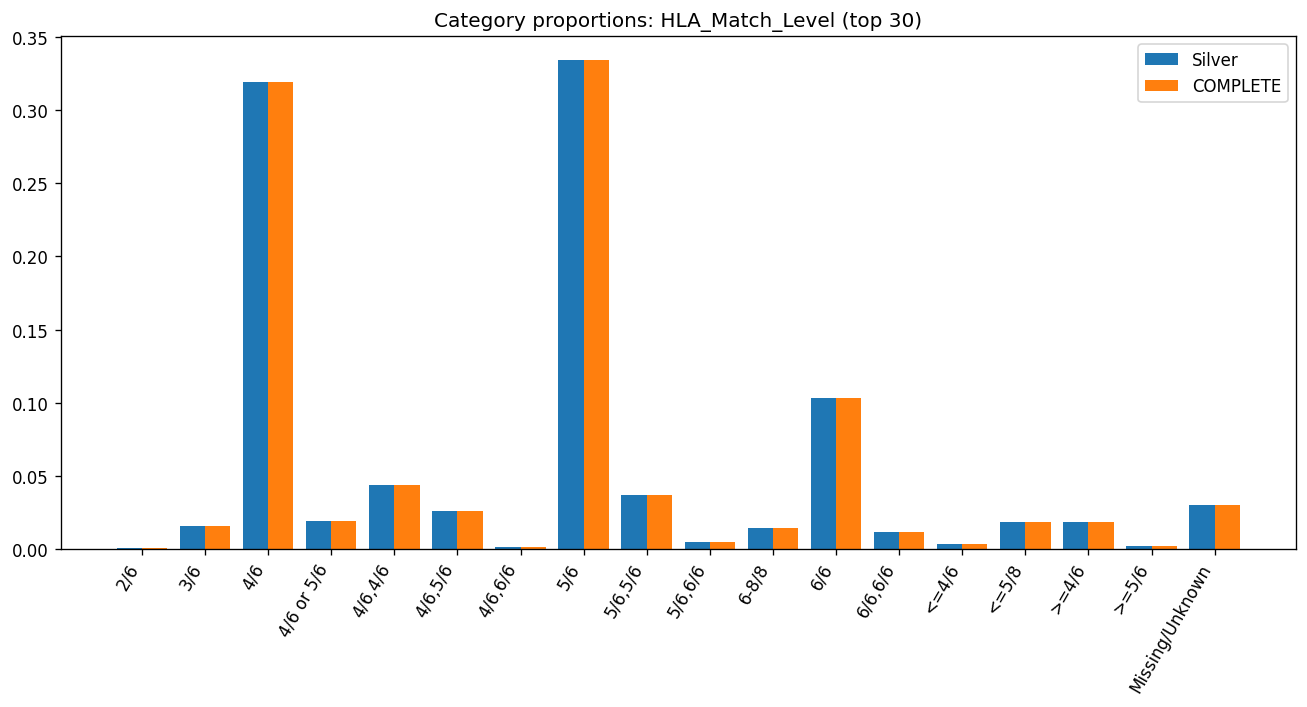


Focused KS p-values (COMPLETE vs SILVER):
                 p_raw        p_bonf         p_fdr
column                                            
CD34_num  1.788413e-17  1.609572e-16  8.047858e-17
TNC_num   2.351569e-27  2.116412e-26  2.116412e-26

Silver vs COMPLETE_SDV
— KS results (numeric):
                   column   KS_stat         p_raw  n_silver  n_candidate  \
6    Platelet_Engraftment  0.014958  2.169146e-01      6559        20000   
0           Recipient_Age  0.011477  3.324435e-01     10222        20000   
7            Chronic_GVHD  0.008240  7.446490e-01     10222        20000   
8         1_Year_Survival  0.005589  9.910291e-01      8683        20000   
5  Neutrophil_Engraftment  0.001117  1.000000e+00      8818        20000   
2                 TNC_num  0.052790  1.293539e-15      9122        20000   
1                CD34_num  0.053244  2.256905e-12      6391        20000   
3                hla_best  0.042017  2.022154e-10      9914        18942   
4               hla_w

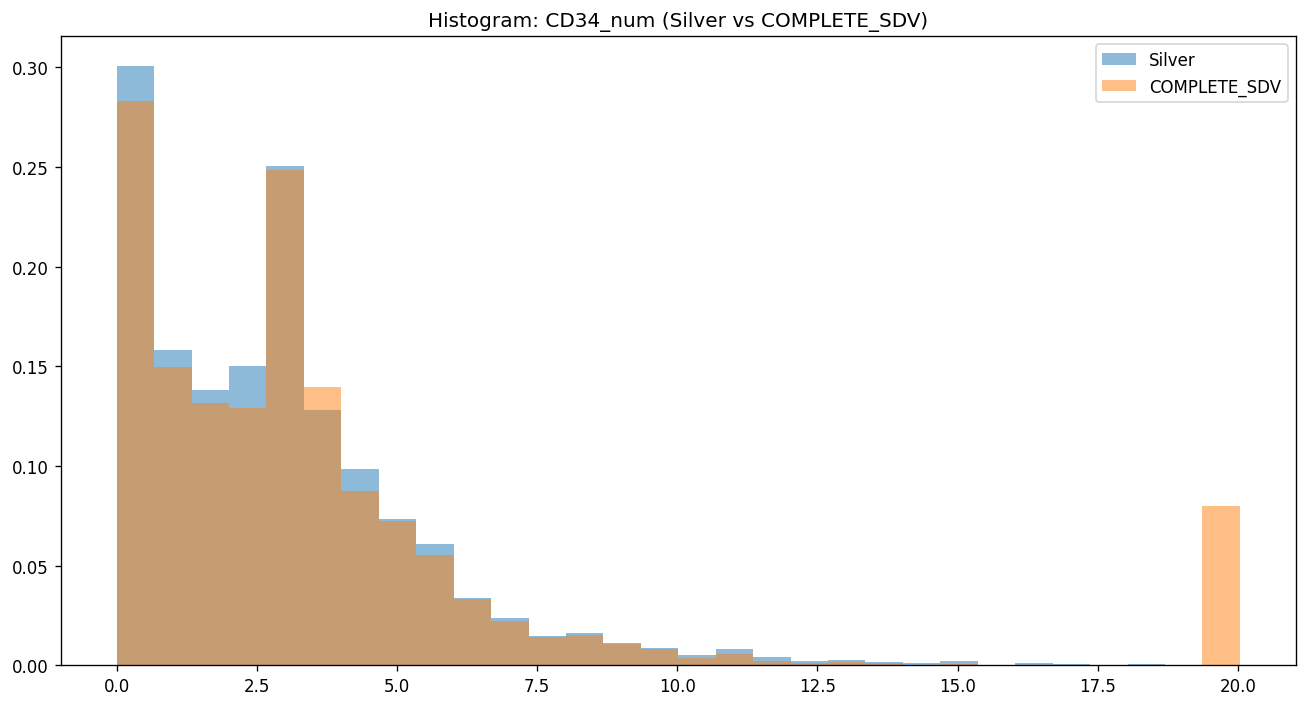

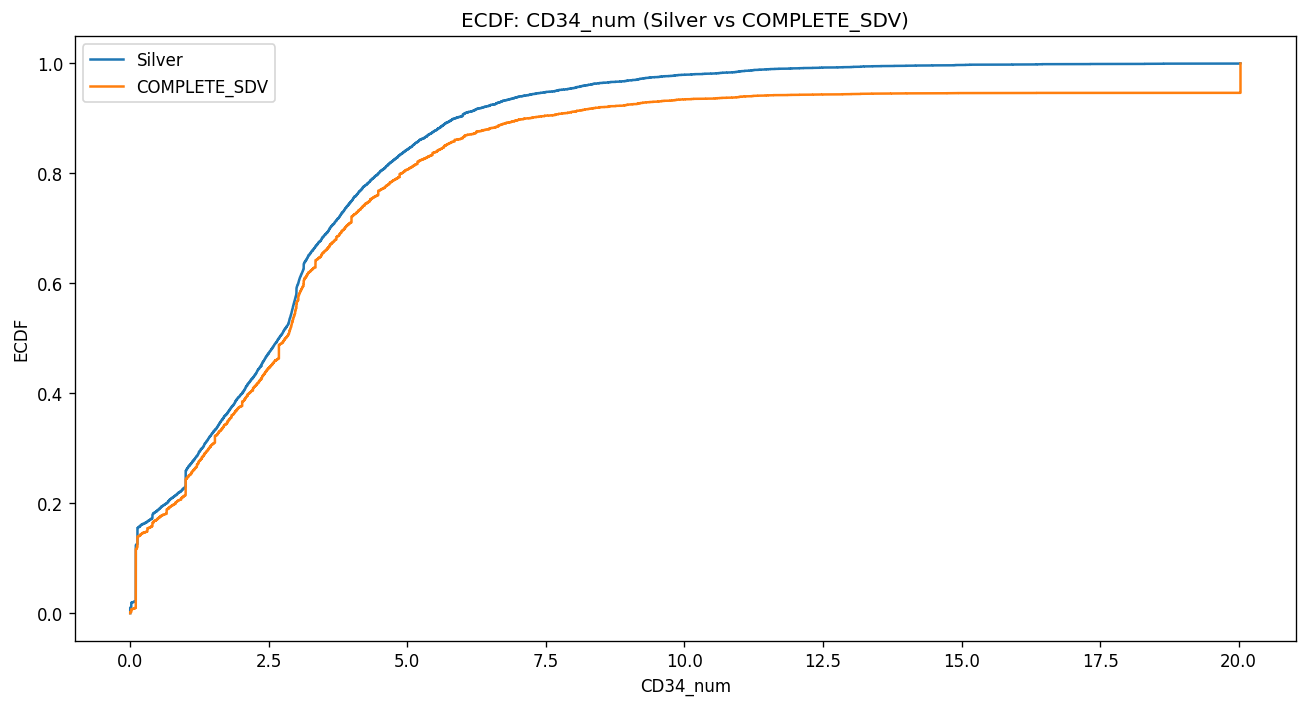

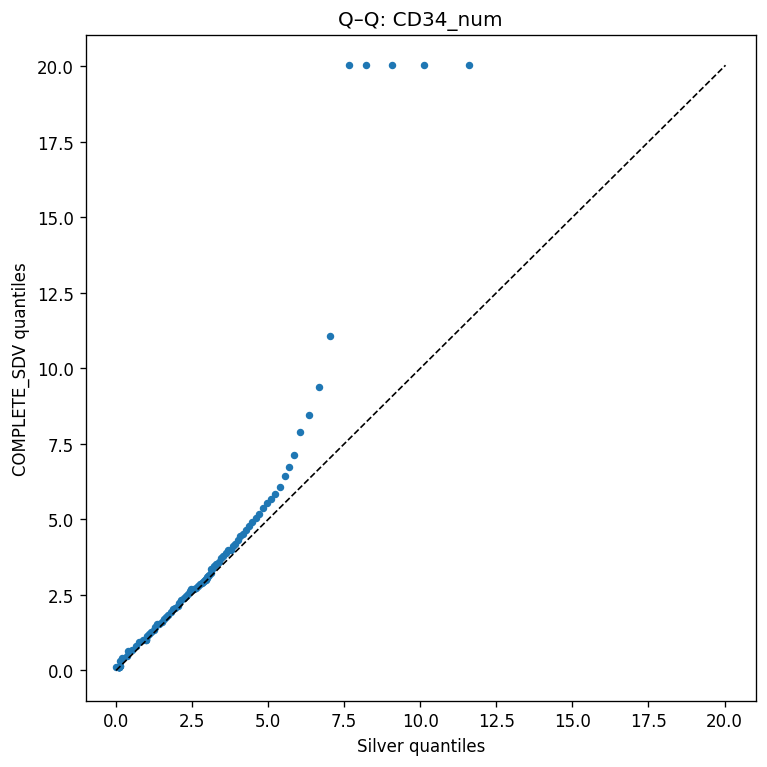

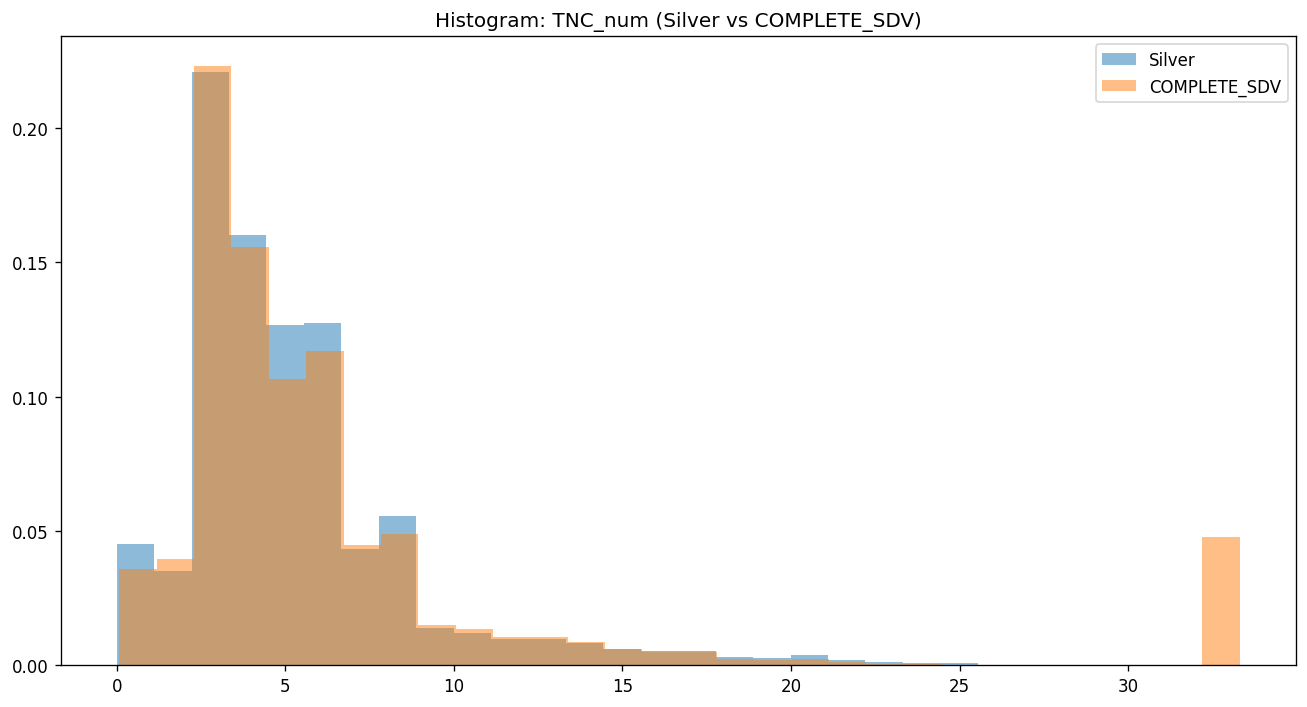

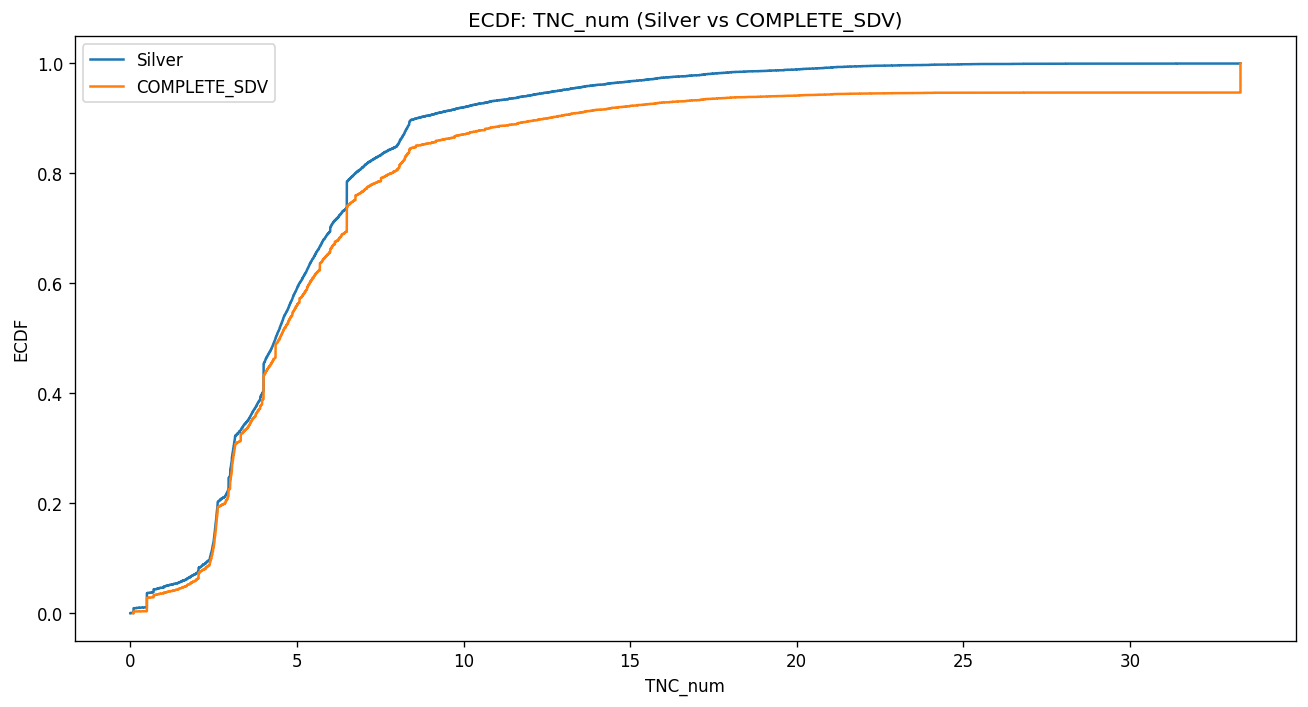

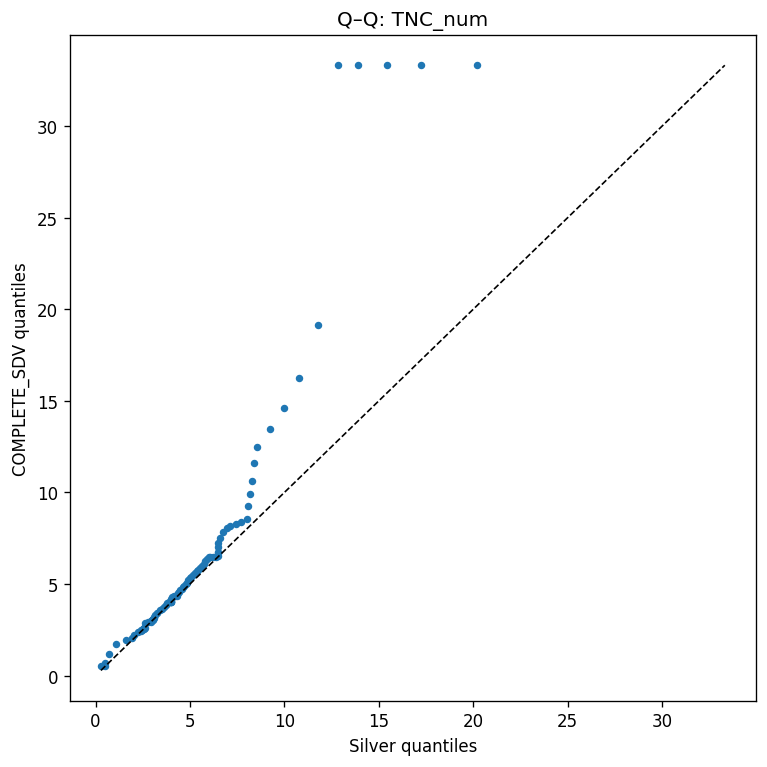

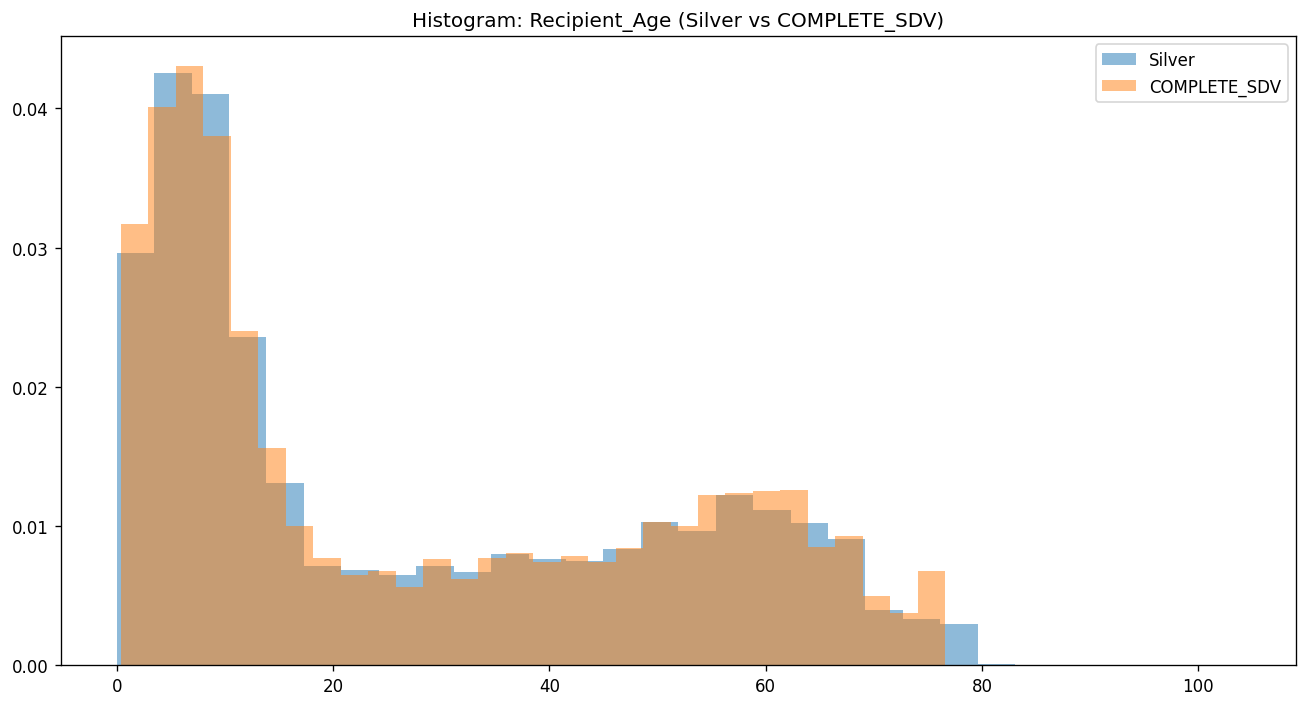

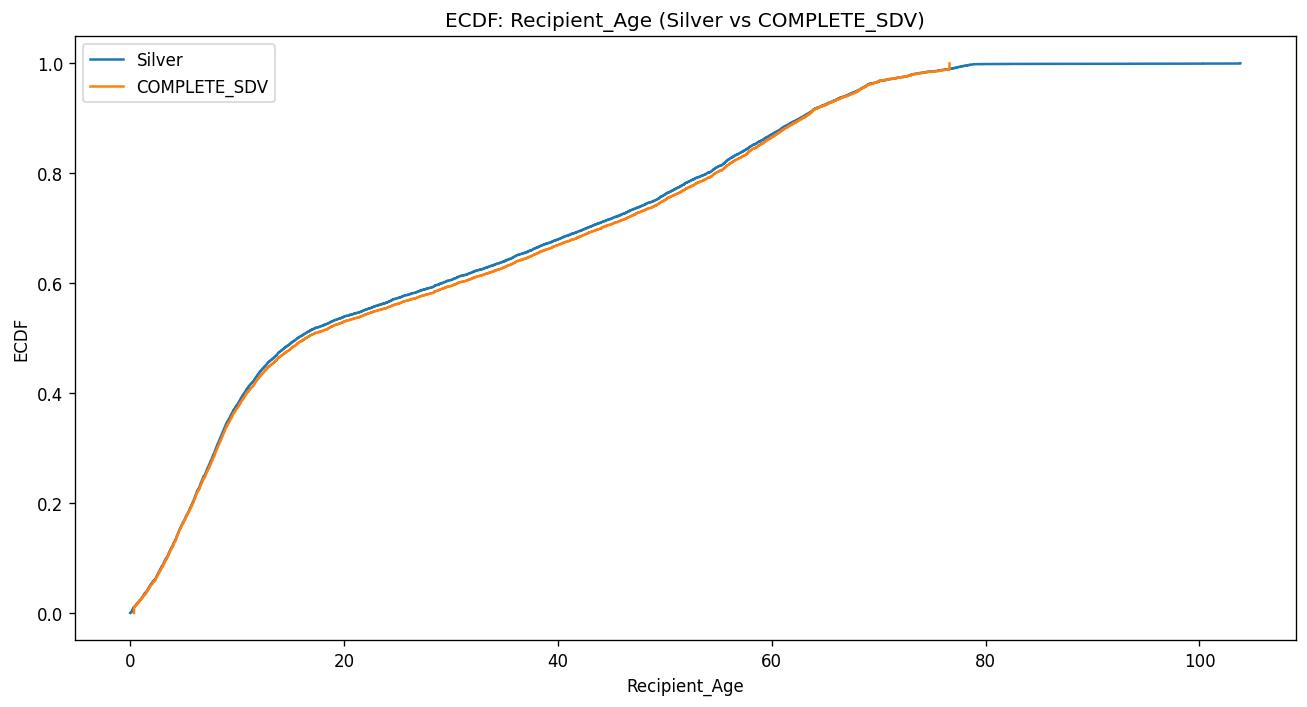

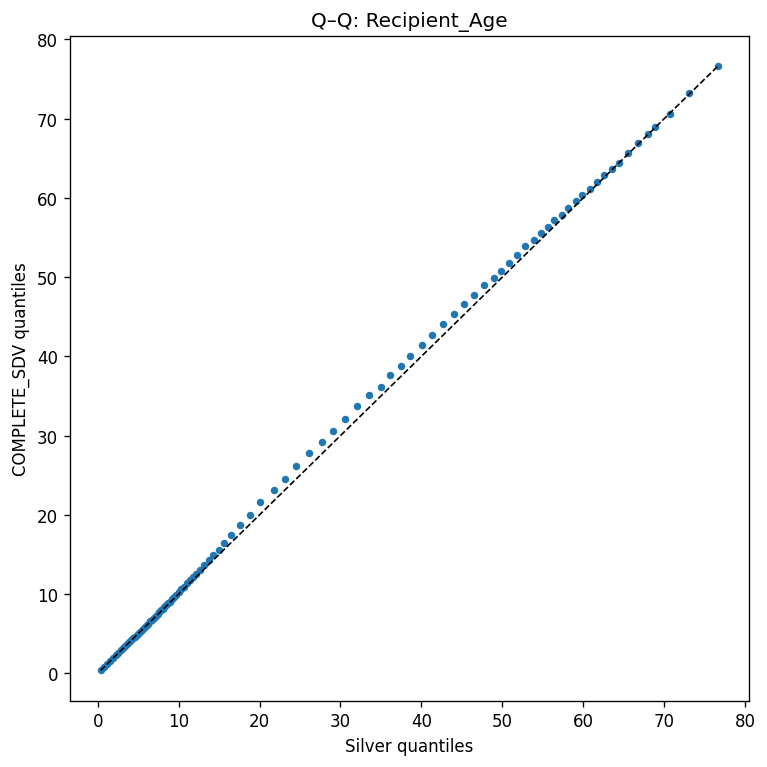

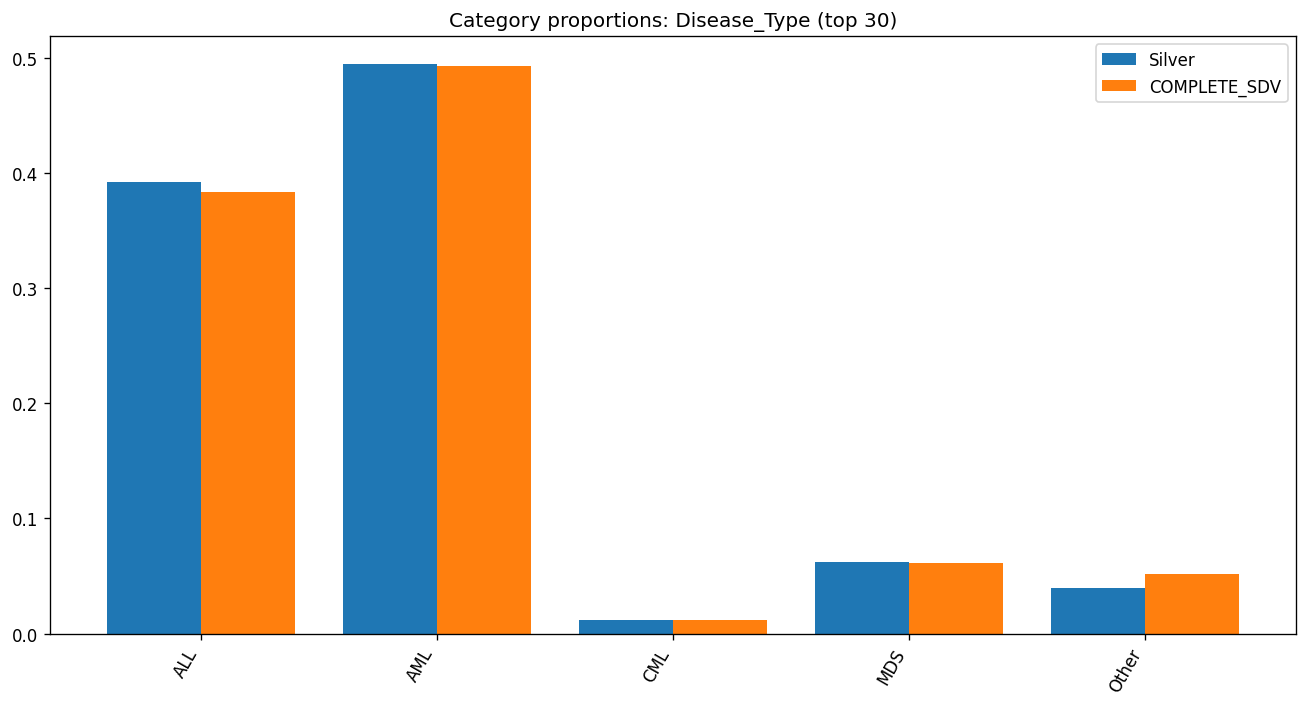

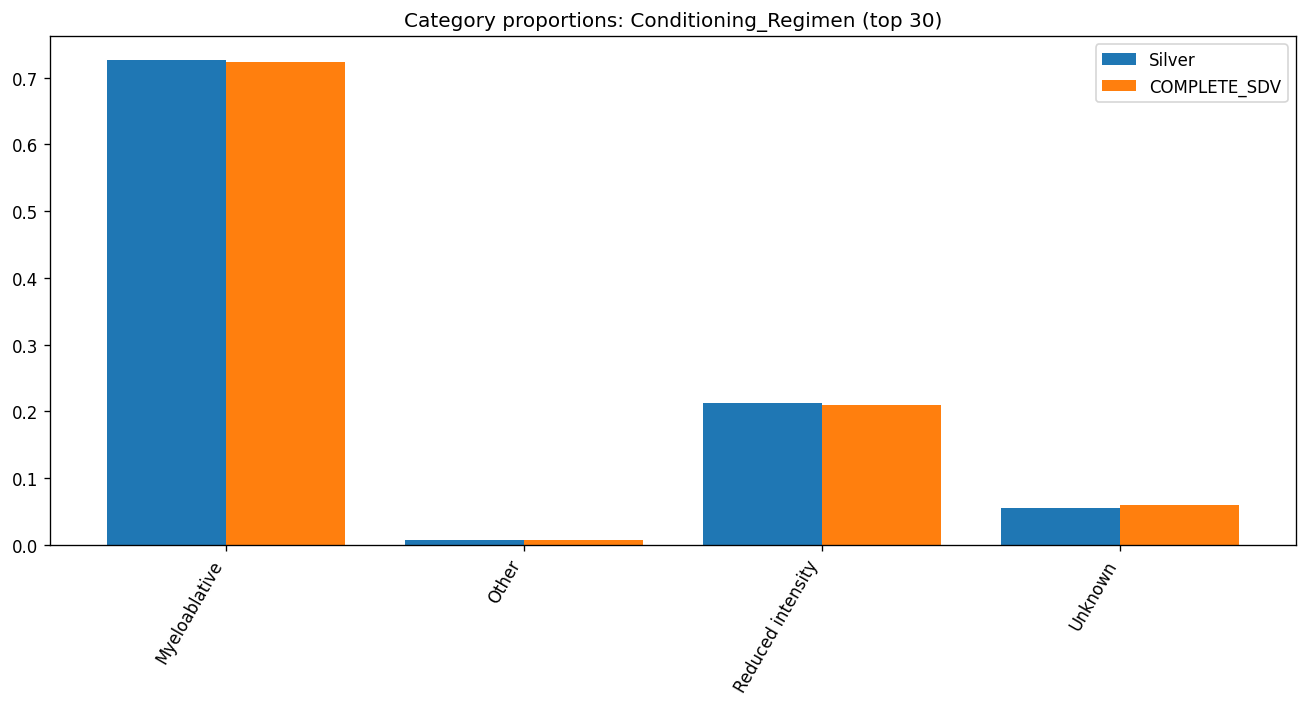

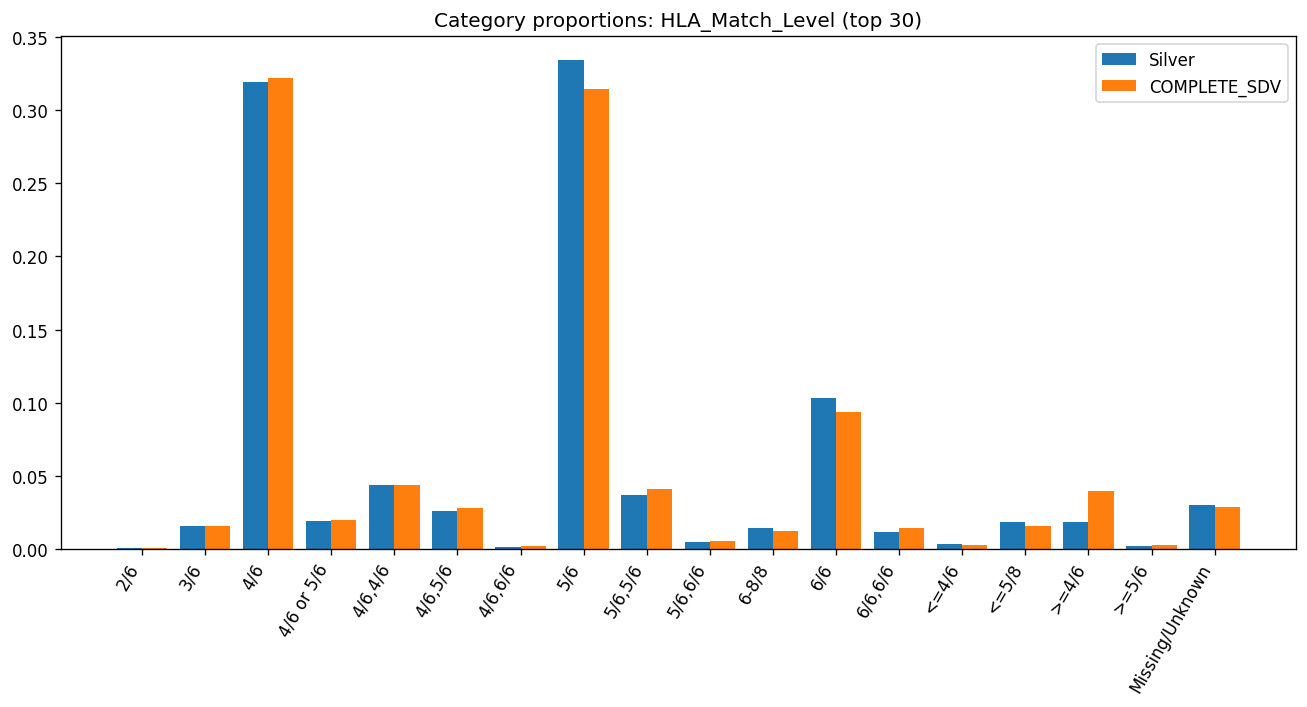


Focused KS p-values (COMPLETE_SDV vs SILVER):
                 p_raw        p_bonf         p_fdr
column                                            
CD34_num  2.256905e-12  2.031214e-11  1.015607e-11
TNC_num   1.293539e-15  1.164185e-14  1.164185e-14
Missingness snapshot (threshold=0.10 for predictors & outcomes)

SILVER: overall missingness (mean across columns) = 0.081
SILVER: top 10 most-missing columns
HLAxCD34                0.404715
CD34_num_pre            0.374780
CD34_num_q_by_DzHLA     0.374780
CD34_num                0.374780
Units_x_CD34            0.374780
log_CD34_num            0.374780
Age_x_CD34              0.374780
Platelet_Engraftment    0.358345
1_Year_Survival         0.150558
HLAxTNC                 0.137742
dtype: float64
SILVER: columns exceeding missingness thresholds
                    column  missing_rate  threshold
0                 HLAxCD34      0.404715        0.1
1             CD34_num_pre      0.374780        0.1
2      CD34_num_q_by_DzHLA      0.374780

In [1]:
# UCBT end-to-end pipeline

import os, re, gc, warnings, traceback, inspect, json, joblib
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import ks_2samp, chisquare
from pandas.api.types import is_numeric_dtype

from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, GroupShuffleSplit,
    StratifiedShuffleSplit, cross_validate, GridSearchCV
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import ADASYN

from xgboost import XGBClassifier


# Repro + paths
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

BASE = Path('/Users/amanda/Desktop/UCBT')
BRONZE = BASE / 'ucbt_dataset.csv'
PARTIAL = BASE / 'ucbt_dataset_partial.csv'
COMPLETE = BASE / 'ucbt_dataset_complete.csv'
COMPLETE_SDV = BASE / 'ucbt_dataset_complete_sdv.csv'
BEST_SYN = BASE / 'ucbt_dataset_synthetic_best.csv'
QC_LOG = BASE / 'qc_log.csv'
print('Paths set:\n -', BRONZE, '\n -', PARTIAL, '\n -', COMPLETE, '\n -', COMPLETE_SDV, '\n -', BEST_SYN)

# Plot cfg
try:
    get_ipython().run_line_magic('matplotlib', 'inline')
    import matplotlib as mpl; mpl.rcParams['figure.dpi'] = 120
except Exception:
    pass
ENABLE_VISUALS = True
SAVE_FIGS = True
FIG_DIR = BASE / "figs_step7"; FIG_DIR.mkdir(exist_ok=True)
FIG_DPI = 220

def _save_or_show(fname: str):
    plt.tight_layout()
    if SAVE_FIGS:
        plt.savefig(FIG_DIR / fname, dpi=FIG_DPI, bbox_inches='tight')
    plt.show()

# STEP 1 — Load BRONZE
bronze = pd.read_csv(BRONZE)
print('Bronze shape:', bronze.shape)
print(bronze.head(5))

# STEP 2 — Helpers
_num_re = re.compile(r'(?P<a>\d+(\.\d+)?)')
_sci_re = re.compile(r'(?P<base>\d+(\.\d+)?)\s*x\s*10\^?(?P<exp>[-+]?\d+)', re.I)

def _midpoint_from_range_txt(txt: str):
    if not isinstance(txt, str): return np.nan
    part = txt.split('x10')[0] if 'x10' in txt else txt
    nums = _num_re.findall(part); vals = [float(n[0]) for n in nums]
    return np.mean(vals[:2]) if len(vals) >= 2 else (float(vals[0]) if vals else np.nan)

def _as_scaled_number(txt, target_exp: int):
    if pd.isna(txt): return np.nan
    if isinstance(txt, (int, float)): return float(txt)
    s = str(txt).replace('≥','>=').replace('≤','<=').strip()
    if '-' in s and 'x10' in s:
        mid = _midpoint_from_range_txt(s)
        m = _sci_re.search(s)
        return mid * (10 ** (int(m.group('exp')) - target_exp)) if m and not np.isnan(mid) else mid
    if any(op in s for op in ['>=','<=','>','<']):
        m = _sci_re.search(s)
        if m: return float(m.group('base')) * (10 ** (int(m.group('exp')) - target_exp))
        n = _num_re.search(s); return float(n.group('a')) if n else np.nan
    m = _sci_re.search(s)
    if m: return float(m.group('base')) * (10 ** (int(m.group('exp')) - target_exp))
    n = _num_re.search(s); return float(n.group('a')) if n else np.nan

def parse_cd34(s): return s.apply(lambda v: _as_scaled_number(v, target_exp=5))  # 10^5/kg
def parse_tnc(s):  return s.apply(lambda v: _as_scaled_number(v, target_exp=7))  # 10^7/kg

def remission_ordinal(val):
    if pd.isna(val): return np.nan
    s = str(val).upper().strip()
    if any(k in s for k in ['RELAP','ACTIVE','REFRACT','NR']): return 0
    if 'CR1' in s or s == '1': return 1
    if 'CR2' in s or s == '2': return 2
    if 'CR3' in s or s == '3': return 3
    try: return float(val)
    except: return np.nan

def hla_to_features(hla):
    if pd.isna(hla):
        return pd.Series({'hla_best': np.nan,'hla_worst': np.nan,'hla_any6': np.nan,'hla_double': np.nan})
    s = str(hla).replace(' ', '').replace('OR', ',').replace('or', ',')
    parts = re.split(r'[;,]+', s) if (',' in s or ';' in s) else [s]
    vals = []
    for p in parts:
        m = re.match(r'(?P<lo>\d+)-(?P<hi>\d+)/(?P<den>\d+)', p)
        if m:
            lo, hi, den = int(m.group('lo')), int(m.group('hi')), int(m.group('den'))
            if den: vals.extend([lo/den, hi/den]); continue
        m = re.match(r'(<=|>=|<|>)(\d+)/(\d+)', p)
        if m:
            num, den = int(m.group(2)), int(m.group(3))
            if den: vals.append(num/den); continue
        m = re.search(r'(\d+)/(\d+)', p)
        if m:
            num, den = int(m.group(1)), int(m.group(2))
            if den: vals.append(num/den)
    if not vals:
        return pd.Series({'hla_best': np.nan,'hla_worst': np.nan,'hla_any6': np.nan,'hla_double': float(len(parts)>1)})
    vals = np.array(vals, float)
    return pd.Series({
        'hla_best':  float(np.nanmax(vals)),
        'hla_worst': float(np.nanmin(vals)),
        'hla_any6':  float(any(np.isclose(vals, 1.0))),
        'hla_double': float(len(parts) > 1)
    })

def round01(s):
    x = pd.to_numeric(s, errors='coerce')
    return x.clip(0,1).round().astype('Int64')

def _quantile_safe(a, q, **kw):
    try: return np.quantile(a, q, method='nearest', **kw)
    except TypeError: return np.quantile(a, q, interpolation='nearest', **kw)

def _learn_cond_platelet_from_silver(silver_df):
    cols = [c for c in ['Neutrophil_Engraftment','Disease_Type','HLA_Match_Level'] if c in silver_df.columns]
    if 'Platelet_Engraftment' not in silver_df.columns or len(cols) < 1:
        return None
    s = silver_df.dropna(subset=['Platelet_Engraftment'] + cols).copy()
    s['Neutrophil_Engraftment'] = pd.to_numeric(s['Neutrophil_Engraftment'], errors='coerce').round()
    grp = s.groupby(cols)['Platelet_Engraftment'].mean().rename('p_platelet')
    return grp

def _apply_cond_platelet(df, cond_p, seed=7):
    """Fill ONLY missing platelet labels using conditional probabilities."""
    if cond_p is None or 'Platelet_Engraftment' not in df.columns:
        return 0
    rng = np.random.default_rng(seed)
    cols = [c for c in ['Neutrophil_Engraftment','Disease_Type','HLA_Match_Level'] if c in df.columns]
    if len(cols) < 1:
        return 0
    df['Neutrophil_Engraftment'] = round01(df['Neutrophil_Engraftment'])
    key = df[cols].copy()
    key['Neutrophil_Engraftment'] = pd.to_numeric(key['Neutrophil_Engraftment'], errors='coerce').round()
    global_p = float(cond_p.mean())
    p_lookup = key.merge(cond_p.reset_index(), on=cols, how='left')['p_platelet'].fillna(global_p).values

    # Only fill NAs
    mask = df['Platelet_Engraftment'].isna()
    n = int(mask.sum())
    if n == 0: return 0
    new_vals = (rng.random(n) < p_lookup[mask]).astype(int)
    before = df.loc[mask, 'Platelet_Engraftment'].copy()
    df.loc[mask, 'Platelet_Engraftment'] = new_vals
    return int((before != df.loc[mask, 'Platelet_Engraftment']).sum())

def _ecdf_local(v):
    v = np.asarray(pd.to_numeric(v, errors='coerce').dropna(), float)
    if v.size == 0: return np.array([]), np.array([])
    v = np.sort(v); y = np.arange(1, v.size+1) / v.size
    return v, y

def _ks_p(col, A, B, min_n=50):
    a = pd.to_numeric(A[col], errors='coerce').dropna()
    b = pd.to_numeric(B[col], errors='coerce').dropna()
    if len(a) < min_n or len(b) < min_n: return np.nan
    return ks_2samp(a, b)[1]

def _quantile_align_complete(dst_df, ref_df, col, strata_cols=None, jitter_frac=0.3, min_ref=50):
    if col not in dst_df.columns or col not in ref_df.columns: return
    ref_num = pd.to_numeric(ref_df[col], errors='coerce')
    ql, qh = np.nanpercentile(ref_num.dropna(), [1, 99])
    iqr = np.nanpercentile(ref_num, 75) - np.nanpercentile(ref_num, 25)
    jitter = (jitter_frac * max(iqr, 1e-6))
    x = pd.to_numeric(dst_df[col], errors='coerce').astype(float).copy()
    if jitter > 0: x = x + np.random.normal(0.0, jitter, size=len(x))
    x = pd.Series(x).clip(lower=max(0.0, ql), upper=qh)
    gqx, _ = _ecdf_local(ref_num)
    if gqx.size == 0: dst_df[col] = x; return
    out = x.copy()
    scols = [c for c in (strata_cols or []) if c in ref_df.columns and c in dst_df.columns]
    if scols:
        ref_key = ref_df[scols].astype('object'); dst_key = dst_df[scols].astype('object')
        for key_vals, idx in dst_key.groupby(scols, dropna=False).groups.items():
            if isinstance(key_vals, tuple):
                mask = (ref_key == pd.Series(key_vals, index=scols)).all(axis=1)
            else:
                mask = (ref_key[scols[0]] == key_vals)
            ref_slice = ref_num.loc[mask]
            rq, _ = _ecdf_local(ref_slice)
            grid = rq if rq.size >= min_ref else gqx
            vals = out.loc[idx].values.astype(float)
            order = np.argsort(vals)
            ranks = np.empty_like(order, dtype=float); ranks[order] = (np.arange(1, vals.size+1) / vals.size)
            mapped = _quantile_safe(grid, np.clip(ranks, 1e-6, 1-1e-6))
            out.loc[idx] = mapped
        dst_df[col] = out
    else:
        vals = out.values.astype(float)
        order = np.argsort(vals)
        ranks = np.empty_like(order, dtype=float); ranks[order] = (np.arange(1, vals.size+1) / vals.size)
        mapped = _quantile_safe(gqx, np.clip(ranks, 1e-6, 1-1e-6))
        dst_df[col] = mapped

def auto_align_numeric(dst_df, ref_df, col,
                       strata=('HLA_Match_Level','Disease_Type','Conditioning_Regimen','AgeBin','Cord_Blood_Units'),
                       jitters=(0.05, 0.1, 0.3), alpha=0.05, min_ref=50):
    for j in jitters:
        _quantile_align_complete(dst_df, ref_df, col, strata_cols=list(strata), jitter_frac=j, min_ref=min_ref)
        p = _ks_p(col, ref_df, dst_df)
        if not np.isnan(p) and p >= alpha:
            print(f"[auto-align] {col}: KS p={p:.4f} with jitter={j}")
            return
    print(f"[auto-align] {col}: KS still < {alpha} after jitter={jitters[-1]}")

def force_quantile_transplant(dst_df, ref_df, col, strata=('HLA_Match_Level','Disease_Type','Conditioning_Regimen','AgeBin','Cord_Blood_Units'), min_ref=50):
    if col not in dst_df.columns or col not in ref_df.columns: return 0
    sc = [c for c in strata if c in dst_df.columns and c in ref_df.columns]
    changed = 0
    if not sc: sc = [None]
    if sc != [None]:
        ref_key = ref_df[sc].astype('object'); dst_key = dst_df[sc].astype('object')
        groups = dst_key.groupby(sc, dropna=False).groups.items()
    else:
        ref_key = None; groups = [(None, dst_df.index)]
    for key_vals, idx in groups:
        if sc != [None]:
            if isinstance(key_vals, tuple):
                rmask = (ref_key == pd.Series(key_vals, index=sc)).all(axis=1)
            else:
                rmask = (ref_key[sc[0]] == key_vals)
            ref_slice = pd.to_numeric(ref_df.loc[rmask, col], errors='coerce').dropna().values
        else:
            ref_slice = pd.to_numeric(ref_df[col], errors='coerce').dropna().values
        dst_slice = pd.to_numeric(dst_df.loc[idx, col], errors='coerce').dropna()
        if len(ref_slice) < min_ref or len(dst_slice) < 3: continue
        ref_slice = np.sort(ref_slice)
        vals = dst_df.loc[dst_slice.index, col].astype(float).values
        order = np.argsort(vals)
        ranks = np.empty_like(order, dtype=float)
        ranks[order] = (np.arange(1, len(vals)+1) / (len(vals)+1))
        mapped = np.quantile(ref_slice, ranks, method='nearest') if hasattr(np, "quantile") else np.percentile(ref_slice, ranks*100)
        before = dst_df.loc[dst_slice.index, col].values.copy()
        dst_df.loc[dst_slice.index, col] = mapped
        changed += int(np.sum(before != mapped))
    return changed

def _largest_remainder_targets(n, pmf):
    cats = pmf.index.tolist()
    raw = pmf.values * n
    base = np.floor(raw).astype(int)
    k = n - base.sum()
    if k > 0:
        rema = raw - base
        add_idx = np.argsort(-rema)[:k]
        base[add_idx] += 1
    return pd.Series(base, index=cats)

def rebalance_to_reference_exact(df, ref, col, group_cols=('Disease_Type',), max_frac=0.45, seed=11):
    rng = np.random.default_rng(seed)
    if col not in df.columns or col not in ref.columns: return 0
    groups = [g for g in group_cols if g in df.columns and g in ref.columns] or [None]
    total_changes = 0
    iter_groups = (df.groupby(groups, dropna=False).groups.items()
                   if groups != [None] else {None: df.index}.items())
    for key, idx in iter_groups:
        dest_slice = df.loc[idx]
        if groups != [None]:
            if isinstance(key, tuple):
                mask = (ref[groups] == pd.Series(key, index=groups)).all(axis=1)
            else:
                mask = (ref[groups[0]] == key)
            pmf = ref.loc[mask, col].dropna().value_counts(normalize=True)
        else:
            pmf = ref[col].dropna().value_counts(normalize=True)
        if pmf.empty: pmf = ref[col].dropna().value_counts(normalize=True)
        if pmf.empty: continue
        n = len(dest_slice)
        tgt = _largest_remainder_targets(n, pmf)
        cur = dest_slice[col].value_counts()
        all_cats = sorted(set(tgt.index) | set(cur.index), key=str)
        tgt = tgt.reindex(all_cats, fill_value=0)
        cur = cur.reindex(all_cats, fill_value=0)
        delta = (cur - tgt)
        surplus = delta[delta > 0].astype(int)
        deficit = (-delta[delta < 0]).astype(int)
        moves_needed = int(deficit.sum())
        if moves_needed == 0: continue
        cap = int(np.ceil(max_frac * n)); moves = min(moves_needed, cap)
        if moves == 0: continue
        take_pool = []
        for cat, s in surplus.items():
            pool = dest_slice.index[dest_slice[col] == cat].tolist()
            if pool: take_pool.extend(rng.choice(pool, size=min(s, len(pool)), replace=False))
        rng.shuffle(take_pool); take_pool = take_pool[:moves]
        if not take_pool: continue
        assign = []
        for cat, d in deficit.items(): assign.extend([cat]*d)
        rng.shuffle(assign); assign = assign[:len(take_pool)]
        before = df.loc[take_pool, col].copy()
        df.loc[take_pool, col] = assign
        total_changes += int((df.loc[take_pool, col] != before).sum())
    return total_changes

def _fill_text_col(dest_df, ref_df, col, strata_col='HLA_Match_Level', rng=None):
    rng = rng or np.random.default_rng(42)
    if col not in dest_df.columns or col not in ref_df.columns: return
    out = dest_df[col].copy()
    miss_idx = out.index[out.isna()]
    if strata_col in ref_df.columns and strata_col in dest_df.columns and len(miss_idx):
        ref = ref_df[[col, strata_col]].dropna(subset=[col])
        for k, idx in dest_df.loc[miss_idx].groupby(dest_df.loc[miss_idx, strata_col]).groups.items():
            choices = ref.loc[ref[strata_col].eq(k), col]
            pmf = choices.value_counts(normalize=True)
            if pmf.empty: pmf = ref[col].value_counts(normalize=True)
            if not pmf.empty:
                out.loc[idx] = rng.choice(pmf.index.to_list(), size=len(idx), p=pmf.values)
    still_miss = out.isna()
    if still_miss.any():
        pmf_g = ref_df[col].dropna().value_counts(normalize=True)
        if not pmf_g.empty:
            out.loc[still_miss] = rng.choice(pmf_g.index.to_list(), size=still_miss.sum(), p=pmf_g.values)
    dest_df[col] = out

def _group_fill_numeric(df, col, by_cols):
    if col not in df.columns: return
    if by_cols:
        med = df[by_cols + [col]].groupby(by_cols, dropna=False)[col].transform('median')
        df[col] = df[col].fillna(med)
    gmed = pd.to_numeric(df[col], errors='coerce').median()
    df[col] = df[col].fillna(gmed)

# STEP 3 — SILVER view
silver = bronze.copy()

silver['Recipient_Age'] = pd.to_numeric(silver['Recipient_Age'], errors='coerce').clip(0,115)
silver['Recipient_Sex'] = pd.to_numeric(silver['Recipient_Sex'], errors='coerce')
silver['Cord_Blood_Units'] = pd.to_numeric(silver['Cord_Blood_Units'], errors='coerce')
silver['Remission_Status'] = silver['Remission_Status'].apply(remission_ordinal)

# Normalise regimen labels (keep canonical text)
if 'Conditioning_Regimen' in silver.columns:
    s = silver['Conditioning_Regimen'].astype(str).str.strip().str.lower()
    silver['Conditioning_Regimen'] = s.replace({
        'myeloablative':'Myeloablative',
        'reduced intensity':'Reduced intensity',
        'reduced-intensity':'Reduced intensity',
        'other':'Other','missing':'Missing','unknown':'Unknown'
    })

# Prefer existing numeric CD34/TNC -> _pre -> parsed text
def _num(s): return pd.to_numeric(s, errors='coerce')
cd34_text = parse_cd34(silver['CD34_Dose']) if 'CD34_Dose' in silver.columns else pd.Series(np.nan, index=silver.index)
tnc_text  = parse_tnc(silver['TNC_Dose'])   if 'TNC_Dose'  in silver.columns else pd.Series(np.nan, index=silver.index)
silver['CD34_num'] = (
    (_num(silver['CD34_num']) if 'CD34_num' in silver.columns else pd.Series(np.nan, index=silver.index))
    .combine_first(_num(silver['CD34_num_pre']) if 'CD34_num_pre' in silver.columns else pd.Series(np.nan, index=silver.index))
    .combine_first(cd34_text)
)
silver['TNC_num'] = (
    (_num(silver['TNC_num']) if 'TNC_num' in silver.columns else pd.Series(np.nan, index=silver.index))
    .combine_first(_num(silver['TNC_num_pre']) if 'TNC_num_pre' in silver.columns else pd.Series(np.nan, index=silver.index))
    .combine_first(tnc_text)
)

# HLA derived features
silver = pd.concat([silver, silver['HLA_Match_Level'].apply(hla_to_features)], axis=1)

# Outcomes as numeric/binary
for y in ['Neutrophil_Engraftment','Platelet_Engraftment','Chronic_GVHD','1_Year_Survival']:
    if y in silver.columns:
        s = pd.to_numeric(silver[y], errors='coerce')
        if y == '1_Year_Survival' and s.isna().any():
            m = silver[y].astype(str).str.upper().map({'YES':1,'Y':1,'TRUE':1,'1':1,'NO':0,'N':0,'FALSE':0,'0':0})
            s = s.fillna(m)
        silver[y] = s.clip(0,1).round().astype('Int64')

print('Silver shape:', silver.shape); print(silver.head(5))

# 3.1 — Derived features
silver['HLAxCD34'] = silver['hla_best'] * silver['CD34_num']
silver['HLAxTNC'] = silver['hla_best'] * silver['TNC_num']
silver['Age_x_CD34'] = silver['Recipient_Age'] * silver['CD34_num']
silver['Age_x_TNC'] = silver['Recipient_Age'] * silver['TNC_num']
silver['log_CD34_num'] = np.log1p(pd.to_numeric(silver['CD34_num'], errors='coerce').clip(lower=0))
silver['log_TNC_num'] = np.log1p(pd.to_numeric(silver['TNC_num'], errors='coerce').clip(lower=0))

if 'Recipient_Age' in silver.columns:
    silver['Age2'] = silver['Recipient_Age'] ** 2
    silver['AgeBin'] = pd.cut(pd.to_numeric(silver['Recipient_Age'], errors='coerce'),
                              bins=[0,5,10,18,40,60,115], include_lowest=True).astype(str)

if {'hla_best','hla_worst'}.issubset(silver.columns):
    silver['hla_mean'] = (pd.to_numeric(silver['hla_best'], errors='coerce') +
                           pd.to_numeric(silver['hla_worst'], errors='coerce')) / 2.0
    silver['hla_range'] = (pd.to_numeric(silver['hla_best'], errors='coerce') -
                           pd.to_numeric(silver['hla_worst'], errors='coerce'))

if 'CD34_num' in silver.columns:
    silver['CD34_adequate'] = (pd.to_numeric(silver['CD34_num'], errors='coerce') >= 3.0).astype(float)
if 'TNC_num' in silver.columns:
    silver['TNC_adequate'] = (pd.to_numeric(silver['TNC_num'], errors='coerce') >= 2.5).astype(float)
if {'CD34_adequate','TNC_adequate'}.issubset(silver.columns):
    silver['Adequacy_Both'] = (silver['CD34_adequate'].eq(1.0) & silver['TNC_adequate'].eq(1.0)).astype(float)

if {'Cord_Blood_Units','CD34_num'}.issubset(silver.columns):
    silver['Units_x_CD34'] = pd.to_numeric(silver['Cord_Blood_Units'], errors='coerce') * pd.to_numeric(silver['CD34_num'], errors='coerce')
if {'Cord_Blood_Units','TNC_num'}.issubset(silver.columns):
    silver['Units_x_TNC'] = pd.to_numeric(silver['Cord_Blood_Units'], errors='coerce') * pd.to_numeric(silver['TNC_num'], errors='coerce')

if 'Conditioning_Regimen' in silver.columns:
    s = silver['Conditioning_Regimen'].astype(str).str.lower()
    silver['Regimen_MA'] = s.str.contains('myeloablative').astype(float)
    silver['Age_x_RegimenMA'] = silver['Recipient_Age'] * silver['Regimen_MA']

group_cols = [c for c in ['Disease_Type','HLA_Match_Level'] if c in silver.columns]
for dose in ['CD34_num','TNC_num']:
    if dose in silver.columns and group_cols:
        silver[f'{dose}_q_by_DzHLA'] = (
            silver.groupby(group_cols)[dose].transform(lambda s: pd.to_numeric(s, errors='coerce').rank(pct=True))
        )

_cond_platelet = _learn_cond_platelet_from_silver(silver)

# STEP 4 — PARTIAL (KNN + scale)
partial = silver.copy()
num_essential = [
    'Recipient_Age','Recipient_Sex','Cord_Blood_Units','Remission_Status',
    'CD34_num','TNC_num','hla_best','hla_worst','hla_any6','hla_double',
    'Neutrophil_Engraftment','Platelet_Engraftment','Chronic_GVHD','1_Year_Survival',
    'HLAxCD34','HLAxTNC','Age_x_CD34','Age_x_TNC','log_CD34_num','log_TNC_num'
]
knn = KNNImputer(n_neighbors=5, weights='distance')
partial[num_essential] = knn.fit_transform(partial[num_essential])
scaler = MinMaxScaler()
partial[[f'{c}_scaled' for c in num_essential]] = scaler.fit_transform(partial[num_essential])
partial.to_csv(PARTIAL, index=False)
print('Saved PARTIAL ->', PARTIAL, partial.shape)

# STEP 5 — COMPLETE (impute + align)
complete = silver.copy()
knn = KNNImputer(n_neighbors=5, weights='distance')
complete[num_essential] = knn.fit_transform(complete[num_essential])

for c in ['Ethnicity','Race','Disease_Type','Conditioning_Regimen','HLA_Match_Level','CD34_Dose','TNC_Dose']:
    if c in complete.columns and complete[c].isna().any():
        mode_val = complete[c].dropna().mode()
        if not mode_val.empty:
            complete[c] = complete[c].fillna(mode_val.iloc[0])

for b in ['Recipient_Sex','Cord_Blood_Units','hla_any6','hla_double',
          'Neutrophil_Engraftment','Platelet_Engraftment','Chronic_GVHD','1_Year_Survival']:
    if b in complete.columns: complete[b] = round01(complete[b])

if 'Remission_Status' in complete.columns:
    r = pd.to_numeric(complete['Remission_Status'], errors='coerce').round()
    complete['Remission_Status'] = r.clip(0,3).astype('Int64')

scaler = MinMaxScaler()
complete[[f'{c}_scaled' for c in num_essential]] = scaler.fit_transform(complete[num_essential])

if {'Disease_Type', 'HLA_Match_Level'}.issubset(complete.columns):
    complete['Dz_HLA_Interact'] = complete['Disease_Type'].astype(str) + '_' + complete['HLA_Match_Level'].astype(str)

# Rebalance Conditioning
if {'Conditioning_Regimen','Disease_Type'}.issubset(complete.columns) and \
   {'Conditioning_Regimen','Disease_Type'}.issubset(silver.columns):
    changes = rebalance_to_reference_exact(complete, silver, col='Conditioning_Regimen',
                                           group_cols=('Disease_Type',), max_frac=0.45, seed=11)
    print(f"[rebalance_exact] Changed {changes} rows for Conditioning_Regimen (~{100*changes/len(complete):.1f}%).")

# Fill CD34_Dose/TNC_Dose text columns from SILVER PMFs where missing
for c in ['CD34_Dose','TNC_Dose']:
    _fill_text_col(complete, silver, c, strata_col='HLA_Match_Level')
complete.to_csv(COMPLETE, index=False)
print("Patched COMPLETE saved ->", COMPLETE)

# Strengthen *_pre and numeric cores
for col in ['CD34_num_pre','TNC_num_pre']:
    if col in complete.columns:
        by_cols = [c for c in ['Disease_Type','HLA_Match_Level'] if c in complete.columns]
        if by_cols:
            med = complete[by_cols + [col]].groupby(by_cols, dropna=False)[col].transform('median')
            complete[col] = complete[col].fillna(med)
        complete[col] = complete[col].fillna(pd.to_numeric(complete[col], errors='coerce').median())
pre_cols = [c for c in complete.columns if c.endswith('_pre')]
pre_num = []
for c in pre_cols:
    complete[c] = pd.to_numeric(complete[c], errors='coerce') if not is_numeric_dtype(complete[c]) else complete[c]
    if is_numeric_dtype(complete[c]): pre_num.append(c)
if pre_num:
    knn_pre = KNNImputer(n_neighbors=10, weights='distance')
    complete[pre_num] = knn_pre.fit_transform(complete[pre_num])

# Group-wise fills for core numerics
by1 = [c for c in ['HLA_Match_Level','Disease_Type','Conditioning_Regimen','Remission_Status'] if c in complete.columns]
for c in ['CD34_num','TNC_num','HLAxCD34','HLAxTNC','Age_x_CD34','Age_x_TNC','log_CD34_num','log_TNC_num']:
    _group_fill_numeric(complete, c, by1 if by1 else [])

# Second-pass KNN on core
core = [c for c in [
    'CD34_num','TNC_num','Recipient_Age','hla_best','hla_worst','Remission_Status',
    'HLAxCD34','HLAxTNC','Age_x_CD34','Age_x_TNC','log_CD34_num','log_TNC_num'
] if c in complete.columns]
if core:
    n_k = min(80, max(2, len(complete) - 1))
    knn2 = KNNImputer(n_neighbors=n_k, weights='distance')
    complete[core] = knn2.fit_transform(complete[core])

# Recompute derived
if {'hla_best','CD34_num'}.issubset(complete.columns): complete['HLAxCD34'] = complete['hla_best'] * complete['CD34_num']
if {'hla_best','TNC_num'}.issubset(complete.columns): complete['HLAxTNC'] = complete['hla_best'] * complete['TNC_num']
if {'Recipient_Age','CD34_num'}.issubset(complete.columns): complete['Age_x_CD34'] = complete['Recipient_Age'] * complete['CD34_num']
if {'Recipient_Age','TNC_num'}.issubset(complete.columns): complete['Age_x_TNC'] = complete['Recipient_Age'] * complete['TNC_num']
complete['log_CD34_num'] = np.log1p(pd.to_numeric(complete['CD34_num'], errors='coerce').clip(lower=0))
complete['log_TNC_num']  = np.log1p(pd.to_numeric(complete['TNC_num'], errors='coerce').clip(lower=0))

# Align numeric distributions to SILVER
for col in ['CD34_num','TNC_num']:
    if col in complete.columns and col in silver.columns:
        auto_align_numeric(
            complete, silver, col,
            strata=('HLA_Match_Level','Disease_Type','Conditioning_Regimen','AgeBin','Cord_Blood_Units'),
            jitters=(0.05, 0.1, 0.3), alpha=0.05, min_ref=50
        )
        chg = force_quantile_transplant(
            complete, silver, col,
            strata=('HLA_Match_Level','Disease_Type','Conditioning_Regimen','AgeBin','Cord_Blood_Units'),
            min_ref=50
        )
        if chg: print(f"[force-quantile] COMPLETE {col}: transplanted {chg} values.")

# Platelet NA-only fill
if _cond_platelet is not None:
    chg_complete = _apply_cond_platelet(complete, _cond_platelet, seed=11)
    if chg_complete:
        print(f"[consistency] COMPLETE: filled {chg_complete} platelet labels (NA-only).")

# AgeBin type safety
for _df in [silver, complete]:
    if _df is not None and 'Recipient_Age' in _df.columns:
        if 'AgeBin' not in _df.columns:
            _df['AgeBin'] = pd.cut(pd.to_numeric(_df['Recipient_Age'], errors='coerce'),
                                   bins=[0,5,10,18,40,60,115], include_lowest=True)
        _df['AgeBin'] = _df['AgeBin'].astype(str)

# Final scaling
core_refresh = [c for c in [
    'CD34_num','TNC_num','Recipient_Age','hla_best','hla_worst','Remission_Status',
    'HLAxCD34','HLAxTNC','Age_x_CD34','Age_x_TNC','log_CD34_num','log_TNC_num'
] if c in complete.columns]
scaler_final = MinMaxScaler()
complete[[f'{c}_scaled' for c in core_refresh]] = scaler_final.fit_transform(complete[core_refresh])
complete.to_csv(COMPLETE, index=False)
print("STEP 5 finalized ->", COMPLETE)

# Drop high-missing non-core
CORE_PRED = {'HLA_Match_Level','TNC_num','CD34_num','Disease_Type','Recipient_Age','Conditioning_Regimen','Remission_Status','Ethnicity','Race','Dz_HLA_Interact'}
DERIVED_TO_TRY_IMPUTE = {'CD34_num_q_by_DzHLA','TNC_num_q_by_DzHLA'}
miss_rate = complete.isna().mean()
hi_miss = [c for c in miss_rate.index[miss_rate > 0.10] if c not in CORE_PRED]
if hi_miss:
    print(f"[hi-missing COMPLETE] dropping {len(hi_miss)} columns (>10% missing): {hi_miss[:6]}{'...' if len(hi_miss)>6 else ''}")
    complete = complete.drop(columns=hi_miss, errors='ignore')
complete.to_csv(COMPLETE, index=False)
for c in ['CD34_Dose','TNC_Dose','Conditioning_Regimen','CD34_num','TNC_num']:
    if c in complete.columns:
        print(f" - {c}: {complete[c].isna().mean():.3f}")

# STEP 6 — SDV (CTGAN/GC) + cleanup
USE_SDV = True
sdv_df = None
try:
    from sdv.metadata import SingleTableMetadata
    from sdv.single_table import CTGANSynthesizer
    HAS_CTGAN = True
except Exception:
    HAS_CTGAN = False
try:
    from sdv.single_table import GaussianCopulaSynthesizer
    HAS_GC = True
except Exception:
    HAS_GC = False

def _clip_like(sdv_s, ref_s, lo=0.01, hi=0.99, lower_floor=0):
    r = pd.to_numeric(ref_s, errors='coerce').dropna()
    if r.empty: return sdv_s
    ql, qh = r.quantile(lo), r.quantile(hi)
    x = pd.to_numeric(sdv_s, errors='coerce')
    return x.clip(lower=max(lower_floor, ql), upper=qh)

def _fill_na_from_pmf(df, col, ref):
    if col not in df.columns or col not in ref.columns: return 0
    if df[col].dtype != 'O': df[col] = df[col].astype('object')
    miss = df[col].isna()
    if not miss.any(): return 0
    pmf = ref[col].dropna().value_counts(normalize=True)
    if pmf.empty: return 0
    n = miss.sum()
    df.loc[miss, col] = np.random.choice(pmf.index.to_list(), size=n, p=pmf.values)
    return int(n)

def _ecdf(v):
    v = np.asarray(v, float); v = v[~np.isnan(v)]
    if v.size == 0: return np.array([]), np.array([])
    v = np.sort(v); y = np.arange(1, v.size+1) / v.size
    return v, y

def _quantile_align_with_jitter(sdv_df, ref_df, col, strata_cols=None, jitter_frac=0.3, min_ref=50):
    if col not in sdv_df.columns or col not in ref_df.columns: return
    ref_num = pd.to_numeric(ref_df[col], errors='coerce')
    ql, qh = np.nanpercentile(ref_num.dropna(), [1, 99])
    iqr = np.nanpercentile(ref_num, 75) - np.nanpercentile(ref_num, 25)
    jitter = (jitter_frac * max(iqr, 1e-6))
    x = pd.to_numeric(sdv_df[col], errors='coerce').astype(float).copy()
    if jitter > 0: x = x + np.random.normal(0.0, jitter, size=len(x))
    x = pd.Series(x).clip(lower=max(0.0, ql), upper=qh)
    gqx, _ = _ecdf_local(ref_num)
    if gqx.size == 0:
        sdv_df[col] = x; return
    out = x.copy()
    scols = [c for c in (strata_cols or []) if c in ref_df.columns and c in sdv_df.columns]
    if scols:
        ref_key = ref_df[scols].astype('object'); dst_key = sdv_df[scols].astype('object')
        for key_vals, idx in dst_key.groupby(scols, dropna=False).groups.items():
            if isinstance(key_vals, tuple):
                rmask = (ref_key == pd.Series(key_vals, index=scols)).all(axis=1)
            else:
                rmask = (ref_key[scols[0]] == key_vals)
            ref_slice = ref_num.loc[rmask]
            rq, _ = _ecdf_local(ref_slice)
            grid = rq if rq.size >= min_ref else gqx
            vals = out.loc[idx].values.astype(float)
            order = np.argsort(vals)
            ranks = np.empty_like(order, dtype=float)
            ranks[order] = (np.arange(1, vals.size+1) / vals.size)
            mapped = _quantile_safe(grid, np.clip(ranks, 1e-6, 1-1e-6))
            out.loc[idx] = mapped
        sdv_df[col] = out
    else:
        vals = out.values.astype(float)
        order = np.argsort(vals)
        ranks = np.empty_like(order, dtype=float); ranks[order] = (np.arange(1, vals.size+1) / vals.size)
        mapped = _quantile_safe(gqx, np.clip(ranks, 1e-6, 1-1e-6))
        sdv_df[col] = mapped

def _fill_binary_from_ref(df, ref, col, strata_cols=('Disease_Type','HLA_Match_Level'), seed=23):
    if col not in df.columns or col not in ref.columns: return 0
    rng = np.random.default_rng(seed)
    miss = df[col].isna()
    if not miss.any(): return 0
    filled = 0
    strata_cols = [c for c in strata_cols if c in df.columns and c in ref.columns]
    if strata_cols:
        key_df = df.loc[miss, strata_cols].astype('object')
        for key, m_idx in key_df.groupby(strata_cols, dropna=False).groups.items():
            if isinstance(key, tuple):
                rmask = (ref[strata_cols] == pd.Series(key, index=strata_cols)).all(axis=1)
            else:
                rmask = (ref[strata_cols[0]] == key)
            p = pd.to_numeric(ref.loc[rmask, col], errors='coerce').mean()
            if np.isnan(p): p = pd.to_numeric(ref[col], errors='coerce').mean()
            if np.isnan(p): continue
            df.loc[m_idx, col] = rng.binomial(1, p, size=len(m_idx))
            filled += len(m_idx)
    miss = df[col].isna()
    if miss.any():
        p = pd.to_numeric(ref[col], errors='coerce').mean()
        if not np.isnan(p):
            df.loc[miss, col] = rng.binomial(1, p, size=miss.sum()); filled += int(miss.sum())
    return filled

# Build SDV training data
sdv_train = silver.copy()
if 'Recipient_Age' in sdv_train.columns and 'AgeBin' not in sdv_train.columns:
    sdv_train['AgeBin'] = pd.cut(pd.to_numeric(sdv_train['Recipient_Age'], errors='coerce'),
                                 bins=[0,5,10,18,40,60,115], include_lowest=True)
if 'AgeBin' in sdv_train.columns:
    sdv_train['AgeBin'] = sdv_train['AgeBin'].astype(str)
if {'Disease_Type', 'HLA_Match_Level'}.issubset(sdv_train.columns):
    sdv_train['Dz_HLA_Interact'] = sdv_train['Disease_Type'].astype(str) + '_' + sdv_train['HLA_Match_Level'].astype(str)
for c in sdv_train.select_dtypes(include=['category']).columns:
    sdv_train[c] = sdv_train[c].astype(str)
sdv_train = sdv_train.drop(columns=[c for c in ['CD34_Dose','TNC_Dose'] if c in sdv_train.columns])
sdv_train = sdv_train.drop(columns=[c for c in sdv_train.columns if c.endswith('_missing')], errors='ignore')

if USE_SDV:
    try:
        from sdv.errors import InvalidDataTypeError
    except Exception:
        class InvalidDataTypeError(Exception): pass

    print("[SDV] Building metadata…")
    meta = SingleTableMetadata(); meta.detect_from_dataframe(sdv_train)
    if 'Patient_ID' in meta.columns: meta.update_column('Patient_ID', sdtype='id')
    for c in ['Ethnicity','Race','Disease_Type','Conditioning_Regimen','HLA_Match_Level','Study_ID','AgeBin','Dz_HLA_Interact']:
        if c in meta.columns: meta.update_column(c, sdtype='categorical')
    for c in ['Recipient_Age','Recipient_Sex','Cord_Blood_Units','Remission_Status',
              'CD34_num','TNC_num','hla_best','hla_worst','hla_any6','hla_double',
              'Neutrophil_Engraftment','Platelet_Engraftment','Chronic_GVHD','1_Year_Survival',
              'HLAxCD34','HLAxTNC','Age_x_CD34','Age_x_TNC','log_CD34_num','log_TNC_num',
              'Age2','hla_mean','hla_range','CD34_adequate','TNC_adequate','Adequacy_Both',
              'Units_x_CD34','Units_x_TNC','Regimen_MA','Age_x_RegimenMA',
              'CD34_num_q_by_DzHLA','TNC_num_q_by_DzHLA']:
        if c in meta.columns: meta.update_column(c, sdtype='numerical')
    try:
        (BASE / 'ucbt_metadata_single_table.json').unlink(missing_ok=True)
        meta.save_to_json(str(BASE / 'ucbt_metadata_single_table.json'))
        print("[SDV] Metadata saved to ucbt_metadata_single_table.json")
    except Exception as e:
        print(f"[SDV] Metadata JSON save failed (ok): {e}")

    if not HAS_CTGAN and not HAS_GC:
        print("[SDV] No synthesizer available — skipping SDV.")
        USE_SDV = False
    else:
        if HAS_CTGAN:
            print("[SDV] Using CTGAN synthesizer.")
            synth = CTGANSynthesizer(
                meta, epochs=600, batch_size=500, pac=10, verbose=True,
                enforce_min_max_values=True, enforce_rounding=True
            )
        else:
            print("[SDV] Using GaussianCopula synthesizer.")
            synth = GaussianCopulaSynthesizer(
                meta, default_distribution='gaussian_kde',
                enforce_min_max_values=True, enforce_rounding=True
            )
        print("[SDV] Fitting synthesizer…")
        try:
            synth.fit(sdv_train)
        except (InvalidDataTypeError, AssertionError, RuntimeError, ValueError) as e:
            if HAS_GC and not isinstance(synth, GaussianCopulaSynthesizer):
                print("[SDV] CTGAN dtype error; falling back to GaussianCopula.")
                synth = GaussianCopulaSynthesizer(
                    meta, default_distribution='gaussian_kde',
                    enforce_min_max_values=True, enforce_rounding=True
                )
                synth.fit(sdv_train)
            else:
                print(f"[SDV] Fit failed: {e}")
                USE_SDV = False

        if USE_SDV:
            print("[SDV] Sampling synthetic table…")
            sdv_df = synth.sample(num_rows=20000)

            # Coerce numerics/binaries
            for c in ['Recipient_Age','Recipient_Sex','Cord_Blood_Units','Remission_Status',
                      'CD34_num','TNC_num','hla_best','hla_worst','hla_any6','hla_double']:
                if c in sdv_df.columns:
                    sdv_df[c] = pd.to_numeric(sdv_df[c], errors='coerce')

            if 'Recipient_Age' in sdv_df.columns:
                sdv_df['Recipient_Age'] = sdv_df['Recipient_Age'].clip(0,115)
                sdv_df['AgeBin'] = pd.cut(pd.to_numeric(sdv_df['Recipient_Age'], errors='coerce'),
                                          bins=[0,5,10,18,40,60,115], include_lowest=True).astype(str)

            if {'Disease_Type', 'HLA_Match_Level'}.issubset(sdv_df.columns):
                sdv_df['Dz_HLA_Interact'] = sdv_df['Disease_Type'].astype(str) + '_' + sdv_df['HLA_Match_Level'].astype(str)

            # Ensure dose text cols exist
            for c in ['CD34_Dose','TNC_Dose']:
                if c not in sdv_df.columns:
                    sdv_df[c] = np.nan

            fixed = 0
            for c in ['Ethnicity','Race','CD34_Dose','TNC_Dose','Conditioning_Regimen','Recipient_Sex','Remission_Status']:
                fixed += _fill_na_from_pmf(sdv_df, c, silver)
            if fixed:
                print(f"[SDV] Filled {fixed} NA(s) in Ethnicity/Race/Doses/Conditioning/Recipient_Sex/Remission_Status from SILVER PMFs.")

            # Round binaries/ints
            for b in ['Recipient_Sex','Cord_Blood_Units','hla_any6','hla_double',
                      'Neutrophil_Engraftment','Platelet_Engraftment','Chronic_GVHD','1_Year_Survival']:
                if b in sdv_df.columns: sdv_df[b] = round01(sdv_df[b])
            if 'Remission_Status' in sdv_df.columns:
                r = pd.to_numeric(sdv_df['Remission_Status'], errors='coerce').round()
                sdv_df['Remission_Status'] = r.clip(0,3).astype('Int64')

            # Outcome rebalance right after rounding outcomes
            OUTCOME_COLS_BIN = ['1_Year_Survival','Neutrophil_Engraftment','Chronic_GVHD']  # (platelet handled by conditional fill)
            for y in OUTCOME_COLS_BIN:
                if y in sdv_df.columns and y in silver.columns:
                    chg_y = rebalance_to_reference_exact(
                        sdv_df, silver, col=y,
                        group_cols=('Disease_Type','HLA_Match_Level'),
                        max_frac=0.35, seed=23
                    )
                    if chg_y:
                        print(f"[SDV rebalance] {y}: changed {chg_y} rows (~{100*chg_y/len(sdv_df):.1f}%).")

            # HLA cleanup/sanitization + rebalance
            if 'HLA_Match_Level' in sdv_df.columns and 'HLA_Match_Level' in silver.columns:
                valid_hla = silver['HLA_Match_Level'].dropna().astype(str).unique().tolist()
                sdv_df['HLA_Match_Level'] = sdv_df['HLA_Match_Level'].where(
                    sdv_df['HLA_Match_Level'].isin(valid_hla), np.nan
                )
                _pmfh = silver['HLA_Match_Level'].dropna().value_counts(normalize=True)
                na_hla = sdv_df['HLA_Match_Level'].isna().sum()
                if na_hla:
                    sdv_df.loc[sdv_df['HLA_Match_Level'].isna(), 'HLA_Match_Level'] = np.random.choice(
                        _pmfh.index, size=na_hla, p=_pmfh.values
                    )
                # Recompute hla_* from cleaned HLA
                hla_feat = sdv_df['HLA_Match_Level'].apply(hla_to_features)
                for k in ['hla_best','hla_worst','hla_any6','hla_double']:
                    if k in hla_feat.columns:
                        if k in ['hla_any6','hla_double']:
                            sdv_df[k] = round01(hla_feat[k])
                        else:
                            sdv_df[k] = pd.to_numeric(hla_feat[k], errors='coerce')

                # Primary HLA rebalance by Disease_Type
                if 'Disease_Type' in sdv_df.columns:
                    hla_changes = rebalance_to_reference_exact(
                        sdv_df, silver, col='HLA_Match_Level',
                        group_cols=('Disease_Type',), max_frac=0.35, seed=19
                    )
                    print(f"[SDV rebalance] HLA_Match_Level: changed {hla_changes} rows (~{100*hla_changes/len(sdv_df):.1f}%).")

                # 2nd-pass HLA rebalance with richer strata
                for gc in [('Disease_Type','Conditioning_Regimen'),
                           ('Disease_Type','AgeBin')]:
                    if all(g in sdv_df.columns and g in silver.columns for g in gc):
                        hla_changes2 = rebalance_to_reference_exact(
                            sdv_df, silver, col='HLA_Match_Level',
                            group_cols=gc, max_frac=0.35, seed=21
                        )
                        if hla_changes2:
                            print(f"[SDV rebalance 2] HLA by {gc}: changed {hla_changes2} rows (~{100*hla_changes2/len(sdv_df):.1f}%).")

            # Numeric alignment + clipping
            strata_cols_num = [c for c in ['HLA_Match_Level','Disease_Type'] if c in silver.columns]
            strata_cols_out = [c for c in ['HLA_Match_Level','Disease_Type','Remission_Status','AgeBin'] if c in silver.columns]
            OUTCOME_COLS = ['Platelet_Engraftment','Neutrophil_Engraftment','1_Year_Survival']
            for col in ['CD34_num','TNC_num','Recipient_Age'] + OUTCOME_COLS:
                if col in sdv_df.columns and col in silver.columns:
                    _quantile_align_with_jitter(
                        sdv_df, silver, col,
                        strata_cols=(strata_cols_out if col in OUTCOME_COLS else strata_cols_num),
                        jitter_frac=0.3, min_ref=50
                    )
                    sdv_df[col] = _clip_like(sdv_df[col], silver[col], lower_floor=0)

            for b in ['Neutrophil_Engraftment','Platelet_Engraftment','Chronic_GVHD',
                      '1_Year_Survival','Recipient_Sex','Cord_Blood_Units','hla_any6','hla_double']:
                if b in sdv_df.columns: sdv_df[b] = round01(sdv_df[b])

            # Stronger numeric alignment loop for stubborn tails
            for col in ['CD34_num','TNC_num']:
                if col in sdv_df.columns and col in silver.columns:
                    for _ in range(3):  # up to three passes
                        auto_align_numeric(
                            sdv_df, silver, col,
                            strata=('HLA_Match_Level','Disease_Type','Conditioning_Regimen','AgeBin','Cord_Blood_Units'),
                            jitters=(0.10, 0.30, 0.50), alpha=0.05, min_ref=50
                        )
                        chg = force_quantile_transplant(
                            sdv_df, silver, col,
                            strata=('HLA_Match_Level','Disease_Type','Conditioning_Regimen','AgeBin','Cord_Blood_Units'),
                            min_ref=50
                        )
                        if chg: print(f"[force-quantile loop] SDV {col}: transplanted {chg} values.")
                        p_now = _ks_p(col, silver, sdv_df)
                        if not np.isnan(p_now) and p_now >= 0.05:
                            break

            # Recompute derived on SDV
            if {'hla_best','CD34_num'}.issubset(sdv_df.columns): sdv_df['HLAxCD34'] = sdv_df['hla_best'] * sdv_df['CD34_num']
            if {'hla_best','TNC_num'}.issubset(sdv_df.columns): sdv_df['HLAxTNC'] = sdv_df['hla_best'] * sdv_df['TNC_num']
            if {'Recipient_Age','CD34_num'}.issubset(sdv_df.columns): sdv_df['Age_x_CD34'] = sdv_df['Recipient_Age'] * sdv_df['CD34_num']
            if {'Recipient_Age','TNC_num'}.issubset(sdv_df.columns): sdv_df['Age_x_TNC'] = sdv_df['Recipient_Age'] * sdv_df['TNC_num']
            if 'CD34_num' in sdv_df.columns: sdv_df['log_CD34_num'] = np.log1p(pd.to_numeric(sdv_df['CD34_num'], errors='coerce').clip(lower=0))
            if 'TNC_num' in sdv_df.columns:  sdv_df['log_TNC_num']  = np.log1p(pd.to_numeric(sdv_df['TNC_num'], errors='coerce').clip(lower=0))

            # Platelet NA-only fill
            if _cond_platelet is not None:
                chg_sdv = _apply_cond_platelet(sdv_df, _cond_platelet, seed=17)
                if chg_sdv: print(f"[consistency] SDV: filled {chg_sdv} platelet labels (NA-only).")

            # Outcome rebalance with finer strata
            for y in OUTCOME_COLS_BIN:
                if all(col in sdv_df.columns for col in [y,'Disease_Type','HLA_Match_Level','Remission_Status','AgeBin']) and y in silver.columns:
                    chg_y2 = rebalance_to_reference_exact(
                        sdv_df, silver, col=y,
                        group_cols=('Disease_Type','HLA_Match_Level','Remission_Status','AgeBin'),
                        max_frac=0.50, seed=23
                    )
                    if chg_y2:
                        print(f"[SDV rebalance+] {y}: changed {chg_y2} rows (~{100*chg_y2/len(sdv_df):.1f}%).")

            # Rebalance Dz and Regimen
            if 'Disease_Type' in sdv_df.columns and 'Disease_Type' in silver.columns:
                dt_changes = rebalance_to_reference_exact(
                    sdv_df, silver, col='Disease_Type',
                    group_cols=('HLA_Match_Level',), max_frac=0.25, seed=17
                )
                print(f"[SDV rebalance] Disease_Type: changed {dt_changes} rows (~{100*dt_changes/len(sdv_df):.1f}%).")
            cond_changes = rebalance_to_reference_exact(
                sdv_df, silver, col='Conditioning_Regimen',
                group_cols=('Disease_Type',), max_frac=0.25, seed=11
            )
            print(f"[SDV rebalance] Conditioning_Regimen: changed {cond_changes} rows (~{100*cond_changes/len(sdv_df):.1f}%).")

            # Scale
            num_essential_like = [c for c in [
                'Recipient_Age','Recipient_Sex','Cord_Blood_Units','Remission_Status',
                'CD34_num','TNC_num','hla_best','hla_worst','hla_any6','hla_double',
                'Neutrophil_Engraftment','Platelet_Engraftment','Chronic_GVHD','1_Year_Survival',
                'HLAxCD34','HLAxTNC','Age_x_CD34','Age_x_TNC','log_CD34_num','log_TNC_num'
            ] if c in sdv_df.columns]
            if num_essential_like:
                scaler_sdv = MinMaxScaler()
                sdv_df[[f'{c}_scaled' for c in num_essential_like]] = scaler_sdv.fit_transform(sdv_df[num_essential_like])

            if 'Patient_ID' in sdv_df.columns:
                sdv_df['Patient_ID'] = np.random.randint(100000, 999999, size=len(sdv_df))

            sdv_df.to_csv(COMPLETE_SDV, index=False)
            print(f"[SDV] Saved COMPLETE_SDV -> {COMPLETE_SDV} shape={sdv_df.shape}")

            # Drop high-missing non-core from SDV
            CORE_PRED = {'HLA_Match_Level','TNC_num','CD34_num','Disease_Type','Recipient_Age','Conditioning_Regimen','Remission_Status','Ethnicity','Race','Dz_HLA_Interact'}
            miss_rate_sdv = sdv_df.isna().mean()
            to_drop_sdv = [c for c in miss_rate_sdv.index[miss_rate_sdv > 0.10] if c not in CORE_PRED]
            if to_drop_sdv:
                print(f"[hi-missing SDV] dropping {len(to_drop_sdv)} columns (>10% missing): {to_drop_sdv[:6]}{'...' if len(to_drop_sdv)>6 else ''}")
                sdv_df = sdv_df.drop(columns=to_drop_sdv, errors='ignore')
            sdv_df.to_csv(COMPLETE_SDV, index=False)
            print(f"[SDV] Saved COMPLETE_SDV -> {COMPLETE_SDV} shape={sdv_df.shape}")

# STEP 7 — KS/χ² + QC logging
def log_qc(dataset_name, ks_df, chi_df, path=QC_LOG):
    if ks_df is None and chi_df is None: return
    frames = []
    if ks_df is not None: frames.append(ks_df.assign(test='KS', dataset=dataset_name))
    if chi_df is not None: frames.append(chi_df.assign(test='CHI', dataset=dataset_name))
    out = pd.concat(frames, ignore_index=True)
    header = not path.exists()
    out.to_csv(path, mode='a', header=header, index=False)

MIN_SAMPLES = 10
ALPHA = 0.05
TOP_CAT_BARS = 30
NUM_COLS_FOR_KS = [c for c in [
    'Recipient_Age','CD34_num','TNC_num','hla_best','hla_worst',
    'Neutrophil_Engraftment','Platelet_Engraftment','Chronic_GVHD','1_Year_Survival'
] if c in silver.columns]
CAT_COLS_FOR_CHI = [c for c in ['Disease_Type','Conditioning_Regimen','HLA_Match_Level','Dz_HLA_Interact'] if c in silver.columns]

def bonferroni(pvals):
    p = np.asarray(pvals, float); return np.minimum(p * max(len(p),1), 1.0)

def fdr_bh(pvals):
    p = np.asarray(pvals, float); n = len(p)
    if n == 0: return p
    order = np.argsort(p); ranks = np.arange(1, n+1); q = np.empty(n, float)
    q[order] = p[order] * n / ranks
    for i in range(n-2, -1, -1): q[order[i]] = min(q[order[i]], q[order[i+1]])
    return np.minimum(q, 1.0)

def _ks_report(col, a_df, b_df):
    a = pd.to_numeric(a_df[col], errors='coerce').dropna()
    b = pd.to_numeric(b_df[col], errors='coerce').dropna()
    if len(a) < MIN_SAMPLES or len(b) < MIN_SAMPLES: return np.nan, np.nan, len(a), len(b)
    stat, p = ks_2samp(a, b); return stat, p, len(a), len(b)

def _chisq_report(col, a_df, b_df):
    va = a_df[col].value_counts(dropna=False); vb = b_df[col].value_counts(dropna=False)
    cats = sorted(set(va.index) | set(vb.index), key=lambda x: str(x))
    oa = np.array([va.get(c, 0) for c in cats], float); ob = np.array([vb.get(c, 0) for c in cats], float)
    if oa.sum() < MIN_SAMPLES or ob.sum() < MIN_SAMPLES: return np.nan, np.nan, int(oa.sum()), int(ob.sum())
    exp = (oa / oa.sum()) * ob.sum(); exp = np.where(exp == 0, 1e-9, exp)
    stat, p = chisquare(f_obs=ob, f_exp=exp); return stat, p, int(oa.sum()), int(ob.sum())

def _generate_visuals(name, df_b):
    if not ENABLE_VISUALS: return
    for c in [x for x in ['CD34_num','TNC_num','Recipient_Age'] if x in NUM_COLS_FOR_KS and x in df_b.columns]:
        a = pd.to_numeric(silver[c], errors='coerce').dropna()
        b = pd.to_numeric(df_b[c], errors='coerce').dropna()
        if len(a) >= MIN_SAMPLES and len(b) >= MIN_SAMPLES:
            plt.figure(figsize=(11,6))
            plt.hist(a, bins=30, alpha=0.5, label='Silver', density=True)
            plt.hist(b, bins=30, alpha=0.5, label=name, density=True)
            plt.title(f'Histogram: {c} (Silver vs {name})'); plt.legend()
            _save_or_show(f"{name}_hist_{c}.png")
            xa, ya = _ecdf_local(a); xb, yb = _ecdf_local(b)
            plt.figure(figsize=(11,6))
            plt.step(xa, ya, where='post', label='Silver'); plt.step(xb, yb, where='post', label=name)
            plt.xlabel(c); plt.ylabel('ECDF'); plt.title(f'ECDF: {c} (Silver vs {name})'); plt.legend()
            _save_or_show(f"{name}_ecdf_{c}.png")
            q = np.linspace(0.01, 0.99, 99); qa = np.quantile(a, q); qb = np.quantile(b, q)
            plt.figure(figsize=(6.5,6.5))
            plt.scatter(qa, qb, s=12); mn, mx = min(qa.min(), qb.min()), max(qa.max(), qb.max())
            plt.plot([mn,mx],[mn,mx],'k--',lw=1); plt.xlabel('Silver quantiles'); plt.ylabel(f'{name} quantiles'); plt.title(f'Q–Q: {c}')
            _save_or_show(f"{name}_qq_{c}.png")
    for c in [x for x in ['Disease_Type','Conditioning_Regimen','HLA_Match_Level','Dz_HLA_Interact'] if x in CAT_COLS_FOR_CHI and x in df_b.columns]:
        va = silver[c].value_counts(normalize=True).head(TOP_CAT_BARS)
        vb = df_b[c].value_counts(normalize=True).head(TOP_CAT_BARS)
        cats = sorted(set(va.index) | set(vb.index), key=lambda x: str(x))[:TOP_CAT_BARS]
        a_vals = [va.get(k, 0.0) for k in cats]; b_vals = [vb.get(k, 0.0) for k in cats]
        ix = np.arange(len(cats))
        plt.figure(figsize=(max(11, len(cats)*0.6), 6))
        plt.bar(ix-0.2, a_vals, width=0.4, label='Silver')
        plt.bar(ix+0.2, b_vals, width=0.4, label=name)
        plt.title(f'Category proportions: {c} (top {TOP_CAT_BARS})')
        plt.xticks(ix, [str(k)[:24] for k in cats], rotation=60, ha='right'); plt.legend()
        _save_or_show(f"{name}_cat_{c}.png")

def _compare_pair(name, df_b):
    print(f"\nSilver vs {name}")
    ks_rows = []
    for c in NUM_COLS_FOR_KS:
        if c in df_b.columns:
            s, p, n_a, n_b = _ks_report(c, silver, df_b)
            ks_rows.append({'column': c, 'KS_stat': s, 'p_raw': p,'n_silver': n_a, 'n_candidate': n_b})
    if ks_rows:
        ks_df = pd.DataFrame(ks_rows); valid = ks_df['p_raw'].notna()
        if valid.any():
            ks_df.loc[valid, 'p_bonf'] = bonferroni(ks_df.loc[valid, 'p_raw'].values)
            ks_df.loc[valid, 'p_fdr'] = fdr_bh(ks_df.loc[valid, 'p_raw'].values)
            for col in ['p_raw','p_bonf','p_fdr']: ks_df[f'pass({col}>=0.05)'] = (ks_df[col] >= ALPHA)
        print("— KS results (numeric):"); print(ks_df.sort_values(['pass(p_fdr>=0.05)','p_fdr','p_raw'], ascending=[False,True,True]))
    else:
        ks_df = None; print("— KS results: no numeric columns available")
    chi_rows = []
    for c in CAT_COLS_FOR_CHI:
        if c in df_b.columns:
            s, p, n_a, n_b = _chisq_report(c, silver, df_b)
            chi_rows.append({'column': c, 'chi2_stat': s, 'p_raw': p,'n_silver': n_a, 'n_candidate': n_b})
    if chi_rows:
        chi_df = pd.DataFrame(chi_rows); valid = chi_df['p_raw'].notna()
        if valid.any():
            chi_df.loc[valid, 'p_bonf'] = bonferroni(chi_df.loc[valid, 'p_raw'].values)
            chi_df.loc[valid, 'p_fdr'] = fdr_bh(chi_df.loc[valid, 'p_raw'].values)
            for col in ['p_raw','p_bonf','p_fdr']: chi_df[f'pass({col}>=0.05)'] = (chi_df[col] >= ALPHA)
        print("— χ² results (categorical):"); print(chi_df.sort_values(['pass(p_fdr>=0.05)','p_fdr','p_raw'], ascending=[False,True,True]))
    else:
        chi_df = None; print("— χ² results: no categorical columns available")
    _generate_visuals(name, df_b)
    return ks_df, chi_df

ks_df, chi_df = _compare_pair('COMPLETE', complete)
log_qc('COMPLETE', ks_df, chi_df)
if ks_df is not None:
    try:
        print("\nFocused KS p-values (COMPLETE vs SILVER):")
        print(ks_df.set_index('column').loc[['CD34_num','TNC_num'], ['p_raw','p_bonf','p_fdr']])
    except Exception:
        pass

if COMPLETE_SDV.exists():
    try:
        sdv_for_check = sdv_df if 'sdv_df' in globals() and sdv_df is not None else pd.read_csv(COMPLETE_SDV)
        ks_df2, chi_df2 = _compare_pair('COMPLETE_SDV', sdv_for_check)
        log_qc('COMPLETE_SDV', ks_df2, chi_df2)
        if ks_df2 is not None:
            try:
                print("\nFocused KS p-values (COMPLETE_SDV vs SILVER):")
                print(ks_df2.set_index('column').loc[['CD34_num','TNC_num'], ['p_raw','p_bonf','p_fdr']])
            except Exception:
                pass
    except Exception as e:
        print(f"ERROR loading file '{COMPLETE_SDV}': {type(e).__name__}: {e}")

# STEP 8 — Missingness snapshot
print("Missingness snapshot (threshold=0.10 for predictors & outcomes)")
OUTCOME_COLS = ['Neutrophil_Engraftment', 'Platelet_Engraftment', 'Chronic_GVHD', '1_Year_Survival']
MISS_THRESH_DEFAULT = 0.10
MISS_THRESH_OUTCOMES = 0.10
_missingness = lambda df: df.isna().mean().sort_values(ascending=False)

def _warn_above_threshold(name: str, miss: pd.Series) -> None:
    rows = []
    for col, rate in miss.items():
        thr = MISS_THRESH_OUTCOMES if col in OUTCOME_COLS else MISS_THRESH_DEFAULT
        if rate > thr:
            rows.append((col, float(rate), float(thr)))
    if rows:
        print(f"{name}: columns exceeding missingness thresholds")
        print(pd.DataFrame(rows, columns=["column", "missing_rate", "threshold"]).sort_values("missing_rate", ascending=False))

def _report_missing(name: str, df: pd.DataFrame) -> pd.Series:
    miss = _missingness(df)
    print(f"\n{name}: overall missingness (mean across columns) = {miss.mean():.3f}")
    print(f"{name}: top 10 most-missing columns"); print(miss.head(10))
    _warn_above_threshold(name, miss); return miss

silver_miss = _report_missing("SILVER", silver)
complete_miss = _report_missing("COMPLETE", complete)

if COMPLETE_SDV.exists():
    try:
        sdv_disk_df = pd.read_csv(COMPLETE_SDV)
        sdv_miss = _report_missing("COMPLETE_SDV", sdv_disk_df)
        mad_complete = (complete_miss.reindex(silver_miss.index, fill_value=0) - silver_miss).abs().mean()
        mad_sdv = (sdv_miss.reindex(silver_miss.index, fill_value=0) - silver_miss).abs().mean()
        print(f"\nMean abs. difference (missingness) vs SILVER:")
        print(f" - COMPLETE: {mad_complete:.4f}")
        print(f" - COMPLETE_SDV: {mad_sdv:.4f}")
    except Exception as e:
        print(f"ERROR reading SDV file at '{COMPLETE_SDV}': {type(e).__name__}: {e}")
else:
    print("COMPLETE_SDV not found on disk; skipping SDV missingness report.")

# STEP 9 — Pre-validate (XGB + ADASYN)
NUMERIC_FEATURES = [
    'Recipient_Age', 'Recipient_Sex', 'Cord_Blood_Units', 'Remission_Status',
    'CD34_num', 'TNC_num', 'hla_best', 'hla_worst', 'hla_any6', 'hla_double',
    'HLAxCD34', 'HLAxTNC', 'Age_x_CD34', 'Age_x_TNC', 'log_CD34_num', 'log_TNC_num'
]
CAT_FEATURES = ['Disease_Type', 'HLA_Match_Level', 'Ethnicity', 'Race', 'Conditioning_Regimen', 'Dz_HLA_Interact']
OUTCOME_COLS = ['1_Year_Survival', 'Platelet_Engraftment', 'Chronic_GVHD', 'Neutrophil_Engraftment']

cat_encoder_kwargs = {'handle_unknown': 'ignore'}
if 'sparse_output' in inspect.signature(OneHotEncoder).parameters:
    cat_encoder_kwargs['sparse_output'] = False
else:
    cat_encoder_kwargs['sparse'] = False

def _prep_feature_sets(df):
    num = [c for c in NUMERIC_FEATURES if c in df.columns]
    cat = [c for c in CAT_FEATURES if c in df.columns]
    return num, cat

def _preprocess_block(num_cols, cat_cols):
    num_tf = Pipeline([('imp', SimpleImputer(strategy='median')), ('sc', MinMaxScaler())])
    cat_tf = Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                       ('ohe', OneHotEncoder(**cat_encoder_kwargs))])
    return ColumnTransformer([('num', num_tf, num_cols), ('cat', cat_tf, cat_cols)], remainder='drop')

def _best_threshold_for_roc_auc(y_true, proba, lo=0.25, hi=0.75, steps=101):
    grid = np.linspace(lo, hi, steps)
    aucs = [roc_auc_score(y_true, (proba >= t).astype(int)) for t in grid]
    return float(grid[np.argmax(aucs)])

from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score

def validate_model(candidate_df, outcome, random_state=42):
    if outcome not in candidate_df.columns:
        return (np.nan,)*8
    m = candidate_df[outcome].notna()
    if m.sum() < 100 or candidate_df.loc[m, outcome].nunique() < 2:
        return (np.nan,)*8
    X = candidate_df.loc[m].copy()
    y = candidate_df.loc[m, outcome].astype(int).values
    num_cols, cat_cols = _prep_feature_sets(X)
    pre = _preprocess_block(num_cols, cat_cols)

    # 70/30 holdout, group by Study_ID if available
    if 'Study_ID' in X.columns:
        gss = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=random_state)
        tr_pos, te_pos = next(gss.split(X, y, groups=X['Study_ID']))
        tr_idx, te_idx = X.index.values[tr_pos], X.index.values[te_pos]
    else:
        tr_idx, te_idx = train_test_split(X.index, test_size=0.30, random_state=random_state, stratify=y)

    X_tr, X_te = X.loc[tr_idx], X.loc[te_idx]
    y_tr = y[X.index.get_indexer(tr_idx)]
    y_te = y[X.index.get_indexer(te_idx)]

    pipe = ImbPipeline([
        ('pre', pre),
        ('adasyn', ADASYN(random_state=random_state, sampling_strategy=1.0)),
        ('clf', XGBClassifier(
            n_estimators=1800, max_depth=5, learning_rate=0.03,
            subsample=0.9, colsample_bytree=0.9, min_child_weight=2,
            reg_lambda=2.0, reg_alpha=0.0, n_jobs=-1, eval_metric='logloss',
            tree_method='hist', random_state=random_state
        ))
    ])

    param_grid = {
        'clf__n_estimators': [600, 1200, 1800, 2400],
        'clf__max_depth': [3, 5, 7, 9],
        'clf__learning_rate': [0.005, 0.01, 0.03, 0.05],
        'clf__subsample': [0.7, 0.8, 0.9],
        'clf__colsample_bytree': [0.7, 0.8, 0.9],
        'clf__reg_lambda': [0.5, 1.0, 2.0]
    }
    gs = GridSearchCV(pipe, param_grid, scoring='roc_auc', cv=3, n_jobs=-1, refit=True)
    gs.fit(X_tr, y_tr)
    pipe = gs.best_estimator_
    print(f"Best params for {outcome}: {gs.best_params_}")

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=random_state)
    cv_scores = cross_validate(pipe, X_tr, y_tr, cv=cv,
                               scoring=['roc_auc', 'accuracy', 'precision', 'recall'],
                               return_train_score=False, n_jobs=-1)

    tr_i, va_i = train_test_split(X_tr.index, test_size=0.2, random_state=random_state, stratify=y_tr)
    pipe.fit(X_tr.loc[tr_i], y_tr[X_tr.index.get_indexer(tr_i)])
    val_proba = pipe.predict_proba(X_tr.loc[va_i])[:, 1]
    t_star = _best_threshold_for_roc_auc(y_tr[X_tr.index.get_indexer(va_i)], val_proba)

    model_path = BASE / f"validate_xgb_{outcome}.joblib"
    joblib.dump(pipe, model_path)
    with open(BASE / f"validate_xgb_{outcome}_threshold.json", "w") as f:
        json.dump({"threshold": float(t_star)}, f)
    print(f"Saved model and threshold for {outcome}")

    pipe.fit(X_tr, y_tr)
    proba_te = pipe.predict_proba(X_te)[:, 1]
    pred_te = (proba_te >= t_star).astype(int)

    auc_te = roc_auc_score(y_te, proba_te)
    acc_te = accuracy_score(y_te, pred_te)
    prec_te = precision_score(y_te, pred_te, zero_division=0)
    rec_te = recall_score(y_te, pred_te, zero_division=0)

    return (float(cv_scores['test_roc_auc'].mean()), float(cv_scores['test_accuracy'].mean()),
            float(cv_scores['test_precision'].mean()), float(cv_scores['test_recall'].mean()),
            auc_te, acc_te, prec_te, rec_te)

# Run validation
candidates = {'COMPLETE': pd.read_csv(COMPLETE)}
if COMPLETE_SDV.exists():
    candidates['SDV'] = pd.read_csv(COMPLETE_SDV)

rows = []
for name, dfcand in candidates.items():
    for outcome in OUTCOME_COLS:
        auc_cv, acc_cv, prec_cv, rec_cv, auc_te, acc_te, prec_te, rec_te = validate_model(dfcand, outcome)
        if not np.isnan(auc_te):
            rows.append({
                'dataset': name,
                'outcome': outcome,
                'cv_auc_mean': auc_cv,
                'cv_acc_mean': acc_cv,
                'cv_prec_mean': prec_cv,
                'cv_rec_mean': rec_cv,
                'test_auc': auc_te,
                'test_acc': acc_te,
                'test_prec': prec_te,
                'test_rec': rec_te,
                'auc_pass': auc_te >= 0.80
            })

summary = pd.DataFrame(rows).sort_values(['outcome', 'test_auc'], ascending=[True, False])
summary['auc_flag'] = summary.apply(lambda r: "FAIL" if r['test_auc'] < 0.80 else "PASS", axis=1)
print("Validation Summary (3-fold CV + 70/30 holdout):")
print(summary)
summary.to_csv(BASE / 'validation_summary.csv', index=False)
print(f"Saved validation summary to {BASE / 'validation_summary.csv'}")

# Choose best dataset for 1-year survival
if not summary.empty and (summary['outcome'] == '1_Year_Survival').any():
    best = summary[summary['outcome'] == '1_Year_Survival'].sort_values('test_auc', ascending=False).iloc[0]
    best_name = best['dataset']
    best_df = candidates[best_name]
    best_df.to_csv(BEST_SYN, index=False)
    print(f"Best dataset: {best_name} (test_auc={best['test_auc']:.3f}) saved to {BEST_SYN}")
else:
    print("No valid results to select BEST_SYN.")
print("End of script.")
